### Preliminary analysis notebook for exploring ASAP7 voltage data recorded in VIP interneuron dendrites

#### This notebook will seek to:
- Uncover image coding and image selectivity properties of VIP dendrites
- Assess responses of VIP dendrites to image sequences
- Assess image change and image response dynamics
- Determine what gross differences there are between dendrites at different depths (DMDs)
- Determine the inter-session differences in the above

In [1]:
import os
import sys
import glob
import json
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.extraction import load_voltage_roi_transform_h5
from vip_slap2_analysis.voltage import analysis
from vip_slap2_analysis.plotting.plot_psth import plot_voltage_mean_image_response_heatmap
from vip_slap2_analysis.utils.utils import save_figure

import matplotlib.pyplot as plt
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [2]:
%matplotlib inline

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots')

TARGET_MICE = [
852835,
    863774
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#   voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"      # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

#### Resolve sessions and voltage assets

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 13 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,852835_2026-07-23_14-27-27,852835,2,2026-07-23,ASAP8,NaN,40,170,change_detection_passive,A0,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,852835_2026-07-24_12-13-41,852835,3,2026-07-24,ASAP8,NaN,40,170,change_detection_passive,A1,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,852835_2026-07-27_11-59-54,852835,4,2026-07-27,ASAP8,NaN,40,170,change_detection_passive,A2,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,852835_2026-07-28_17-13-56,852835,5,2026-07-28,ASAP8,NaN,40,170,change_detection_passive,B0,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,852835_2026-07-29_10-08-37,852835,6,2026-07-29,ASAP8,NaN,40,170,change_detection_passive,B1,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,852835_2026-07-30_15-04-34,852835,7,2026-07-30,ASAP8,NaN,40,170,change_detection_passive,B2,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,852835_2026-08-01_14-58-35,852835,8,2026-08-01,ASAP8,NaN,40,170,change_detection_passive,G1,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,Post-ablation experiment. Several neurons did ...
7,863774_2026-08-04_08-12-47,863774,2,2026-08-04,ASAP8,NaN,190,120,change_detection_passive,A0,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,DMD2 on top -- geometry worked better
8,863774_2026-08-05_13-17-41,863774,3,2026-08-05,ASAP8,NaN,190,120,change_detection_passive,A1,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,863774_2026-08-06_09-15-41,863774,4,2026-08-06,ASAP8,NaN,190,120,change_detection_passive,A2,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


#### Inspect data structures

In [6]:
import h5py

path = glob.glob(os.path.join(assets[0].session_dir,'**','derived','**','**.h5'),recursive=True)[0]
with h5py.File(path, "r") as f:
    def visit(name, obj):
        if hasattr(obj, "shape"):
            print(name, obj.shape, obj.dtype)
        else:
            print(name)
    f.visititems(visit)

DMD1
DMD1/dff (4, 19290590) float32
DMD1/f0 (4, 19290590) float32
DMD1/f0_model
DMD1/f0_model/f0_bin_centers_sample (362,) float64
DMD1/f0_model/f0_bin_values (4, 362) float32
DMD1/raw_f (4, 19290590) float32
DMD1/roi_ids (4,) |S12
DMD1/sample_epoch (19290590,) int16
DMD1/timebase_sec (19290590,) float64
DMD1/trial_epoch (196,) int16
DMD1/trial_lengths_samples (196,) int64
DMD1/trial_starts_sec (196,) float64
DMD1/trial_valid_mask (196,) bool
DMD1/valid_rois_mask (4,) bool
DMD2
DMD2/dff (3, 19290590) float32
DMD2/f0 (3, 19290590) float32
DMD2/f0_model
DMD2/f0_model/f0_bin_centers_sample (362,) float64
DMD2/f0_model/f0_bin_values (3, 362) float32
DMD2/raw_f (3, 19290590) float32
DMD2/roi_ids (3,) |S12
DMD2/sample_epoch (19290590,) int16
DMD2/timebase_sec (19290590,) float64
DMD2/trial_epoch (196,) int16
DMD2/trial_lengths_samples (196,) int64
DMD2/trial_starts_sec (196,) float64
DMD2/trial_valid_mask (196,) bool
DMD2/valid_rois_mask (3,) bool


#### Explore the data -- mean image responses
##### Strategy
- Grab data assets from the derived folder for each mouse/session
- Plot mean response + image response, change response, omission response as heatmap for each roi x dmd x session
- Make heatmap across all ROIs and sessions

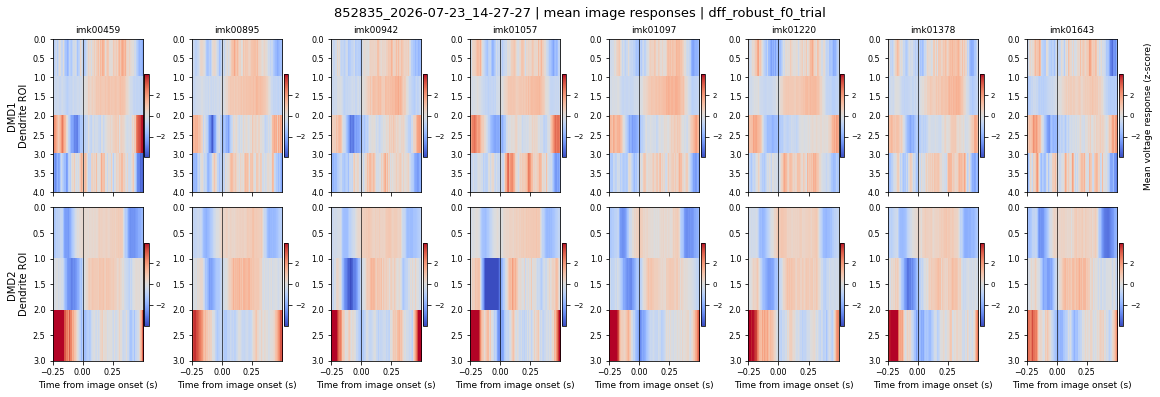

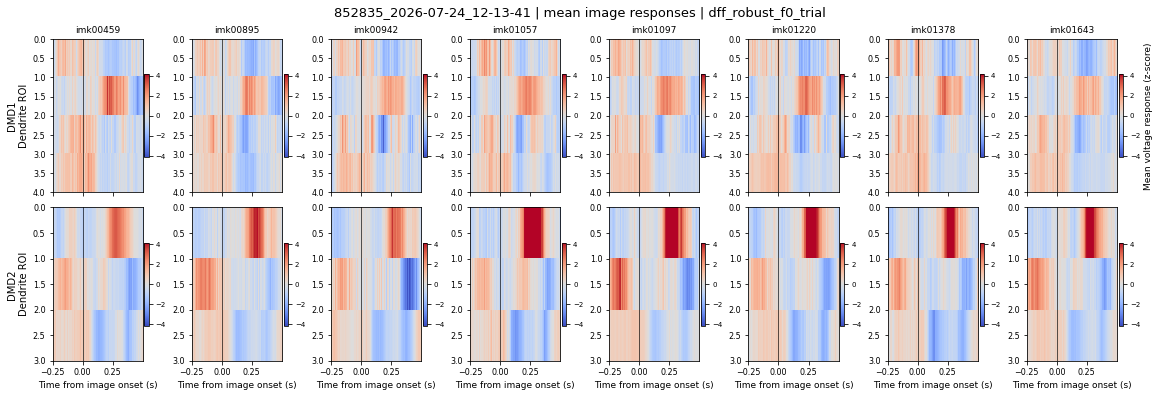

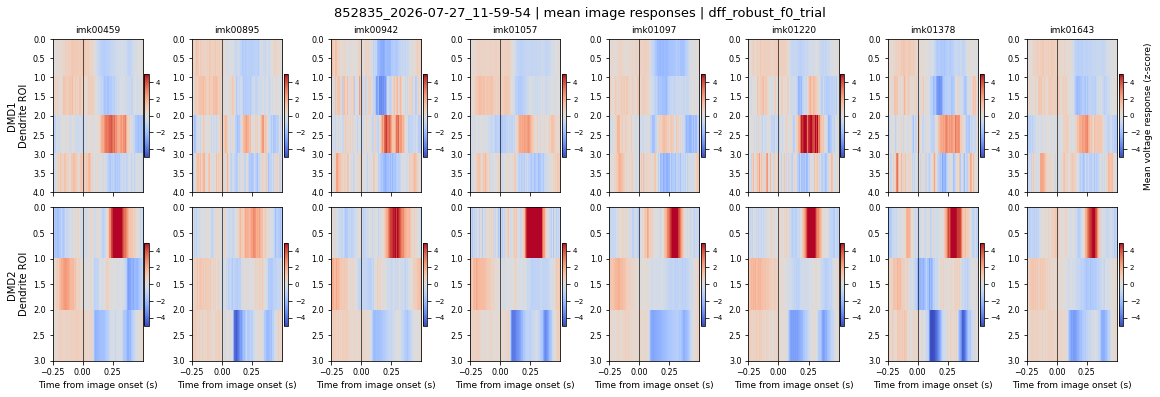

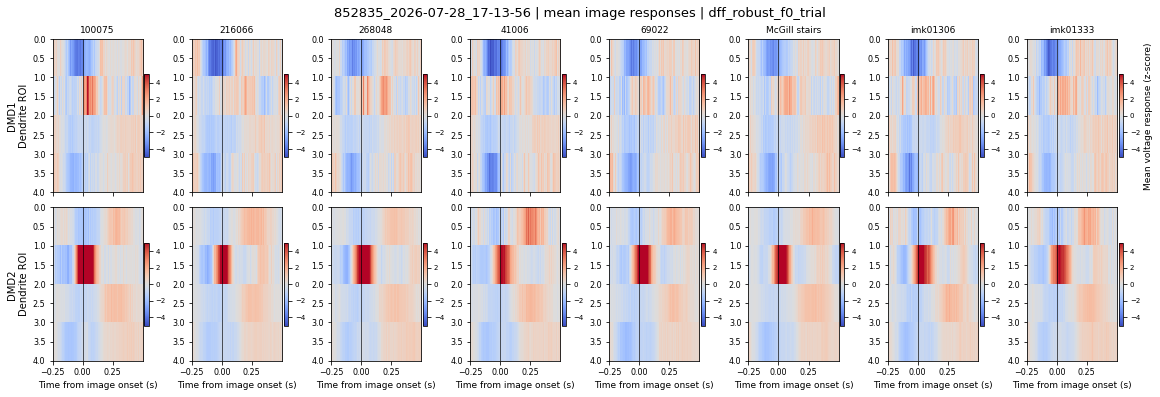

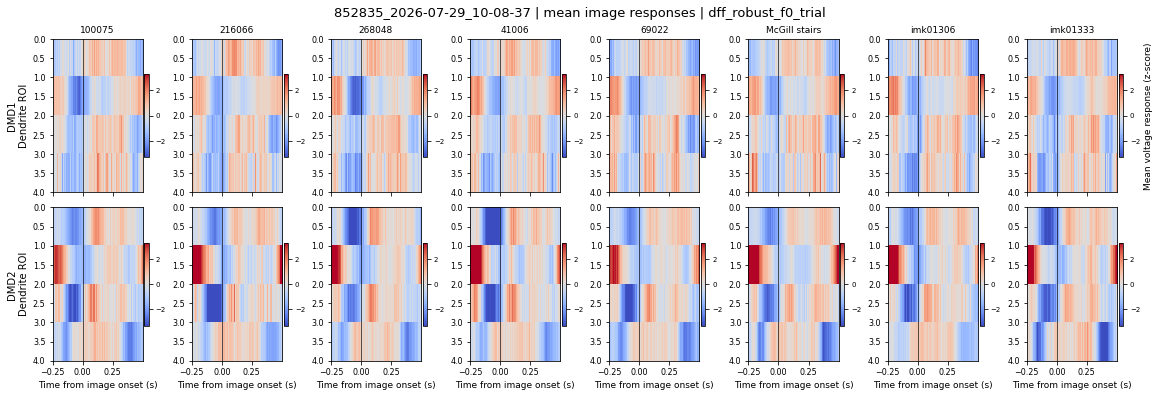

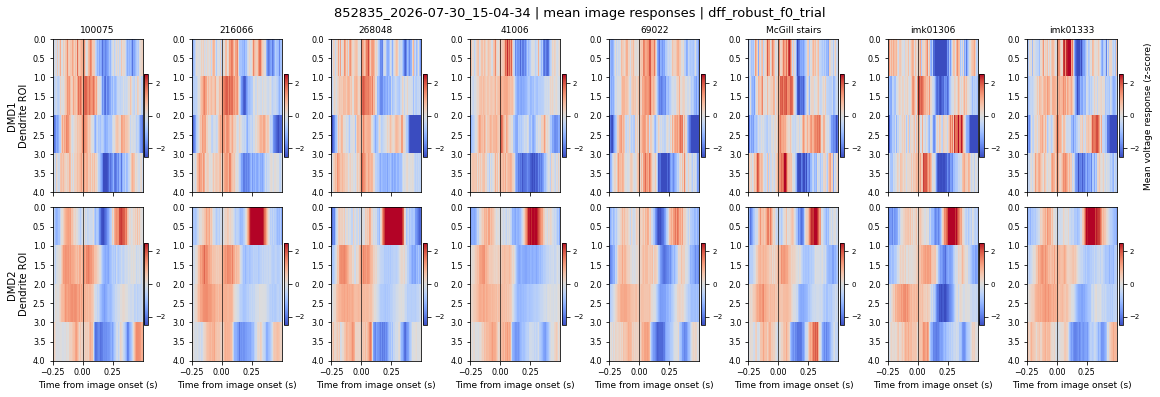

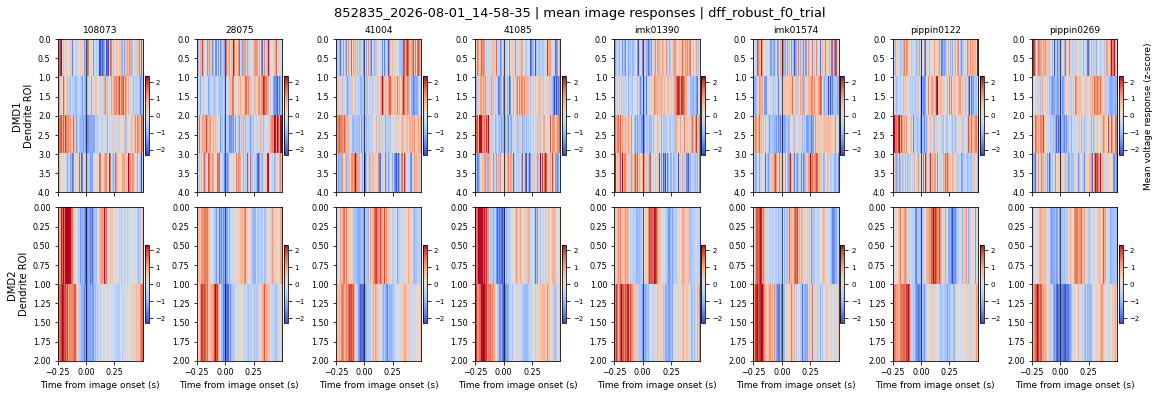

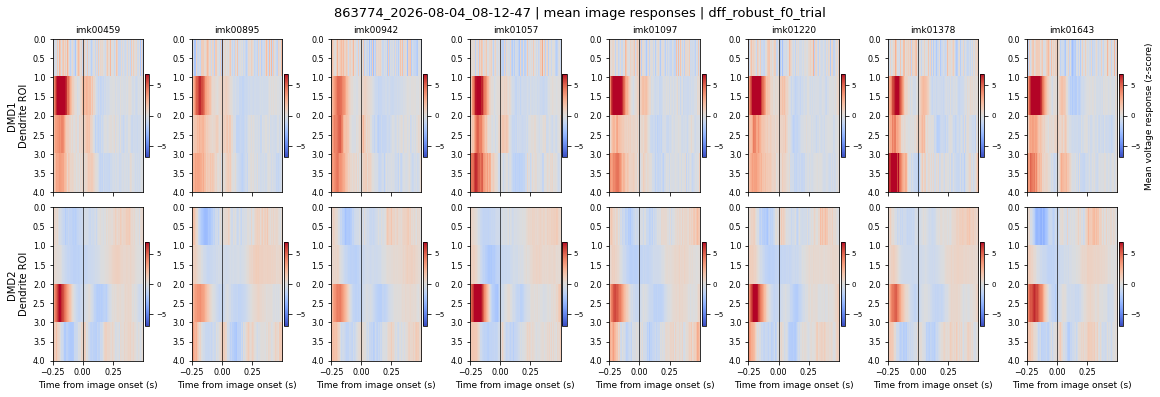

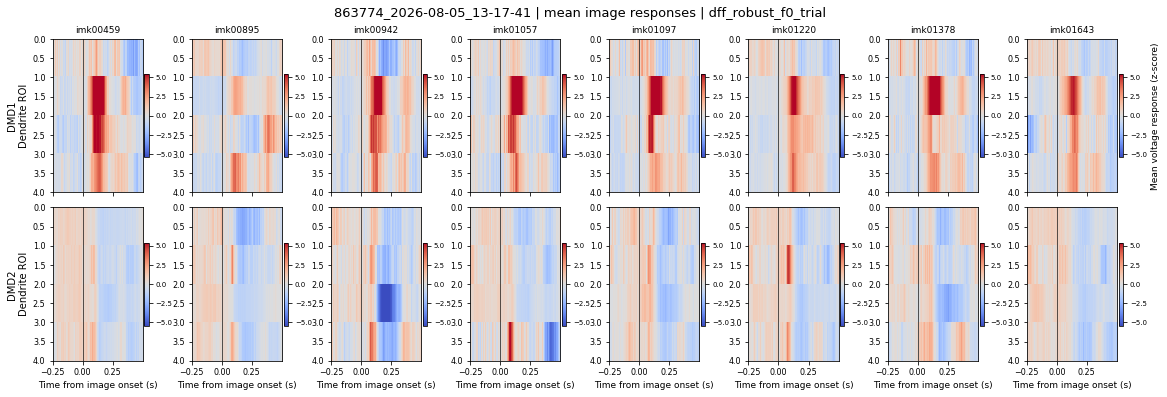

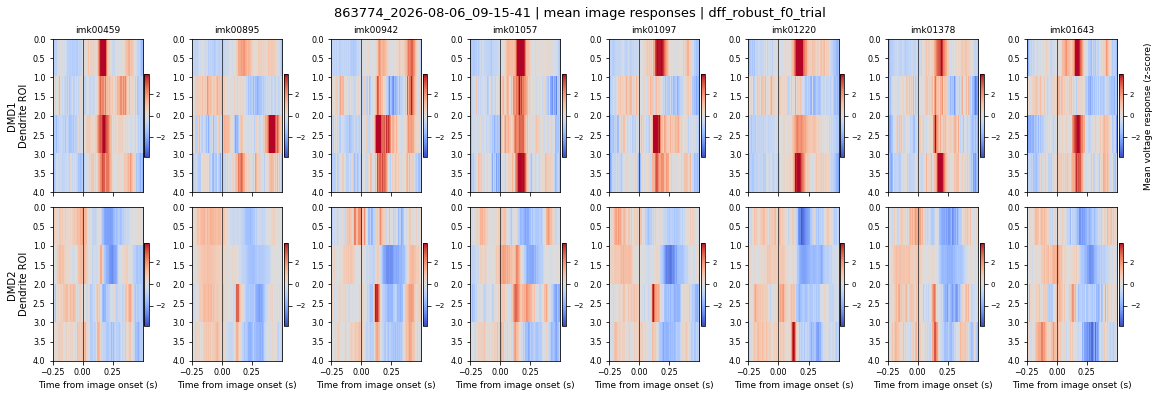

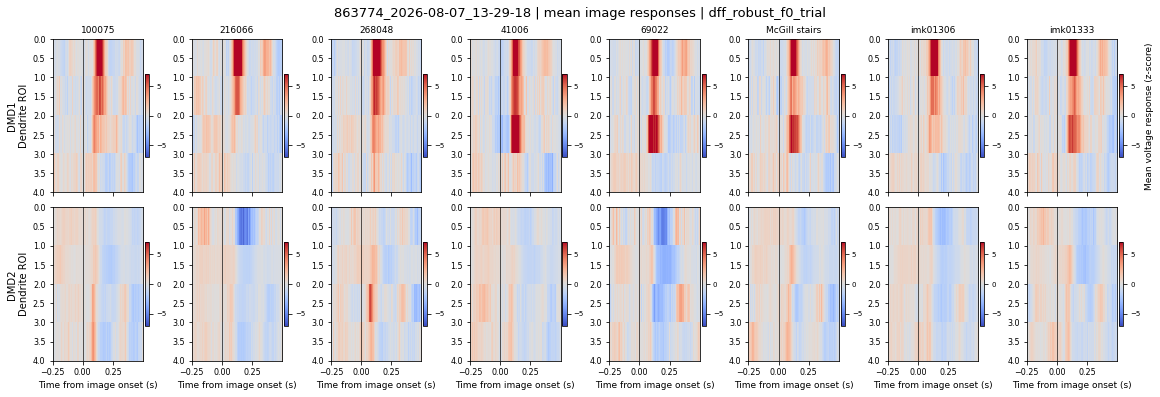

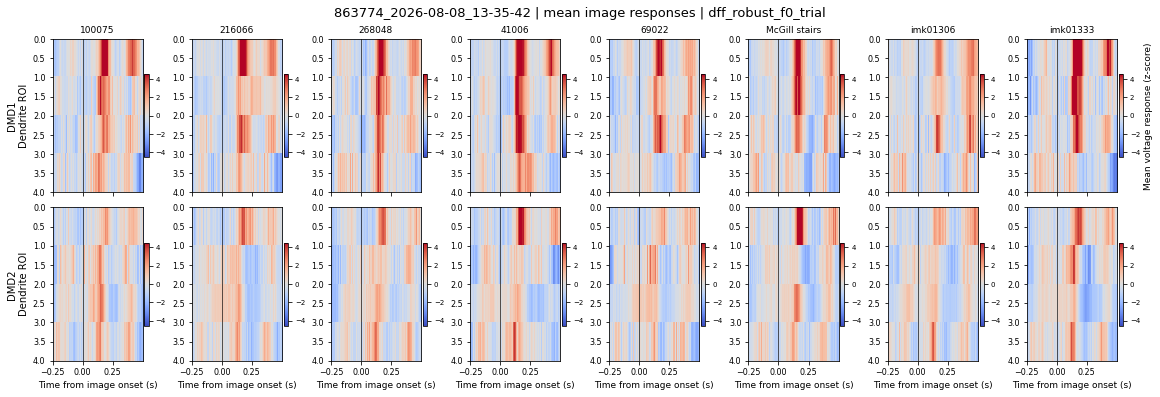

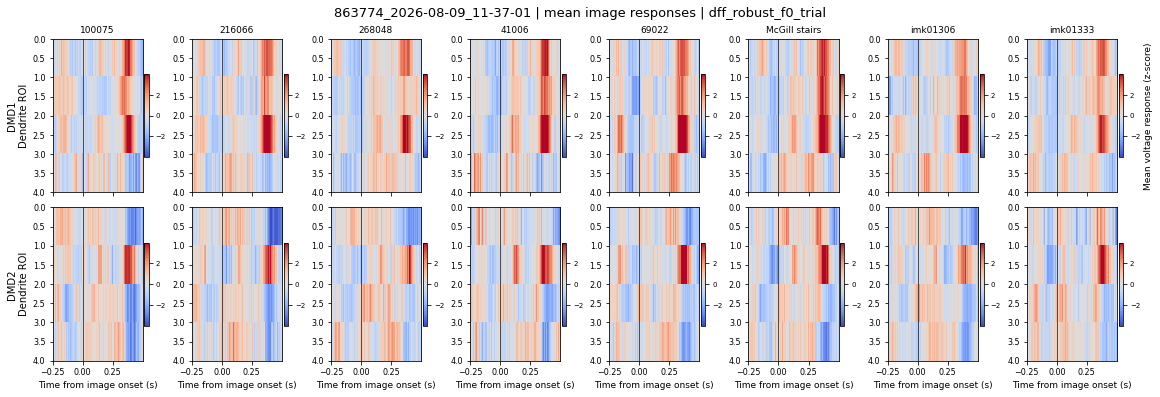

In [7]:
dmds = [1, 2]

# Plot settings
NORMALIZE_ROWS = "zscore"
BASELINE_SUBTRACT = True
BASELINE_WINDOW = (-0.25, 0.0)
SMOOTH_SIGMA = 1
SORT_BY = None  # important: preserves ROI row identity across images within each DMD
CMAP = "coolwarm"
PERCENTILES = (2, 99)
SYMMETRIC_CLIM = True
PER_PANEL_COLORBARS = True  # set False for one shared colorbar per session

def _get_image_names_from_behavior_qc(asset):
    """Return stimulus image names from behavior QC, preserving behavioral order."""
    behavior_qc_matches = glob.glob(
        str(Path(asset.qc_dir) / "behavior" / "behavior_validation.json")
    )
    if not behavior_qc_matches:
        return []

    with open(behavior_qc_matches[0], "r") as f:
        b_qc = json.load(f)

    return b_qc.get("bonsai_validation", {}).get("stimulus_names", [])


def _clean_image_label(image_name):
    """Short panel title from image name/path."""
    if image_name is None:
        return "image"
    stem = Path(str(image_name)).stem
    return stem.replace("_", " ")


def _finite_concat(mats):
    vals = []
    for mat in mats:
        if mat is None:
            continue
        v = np.asarray(mat, dtype=float)
        v = v[np.isfinite(v)]
        if v.size:
            vals.append(v)
    if not vals:
        return np.array([])
    return np.concatenate(vals)


for asset in assets:
    session_id = getattr(asset, "session_id", "session")

    im_names = _get_image_names_from_behavior_qc(asset)

    if len(im_names) == 0:
        print(f"{session_id}: no stimulus_names found in behavior QC; skipping.")
        continue

    # ---------------------------------------------------------------------
    # First pass: collect processed mean-response matrices.
    # This uses the existing single-panel function, then closes its temp fig.
    # ---------------------------------------------------------------------
    panel_data = {}
    collected_mats = []

    for dmd in dmds:
        for im_idx, image_name in enumerate(im_names):
            key = (dmd, im_idx)

            try:
                out = plot_voltage_mean_image_response_heatmap(
                    asset=asset,
                    trace_variant=TRACE_VARIANT,
                    dmd=dmd,
                    image_name=image_name,
                    use_roi_qc=True,
                    normalize_rows=NORMALIZE_ROWS,
                    baseline_subtract=BASELINE_SUBTRACT,
                    baseline_window=BASELINE_WINDOW,
                    smooth_sigma=SMOOTH_SIGMA,
                    sort_by=SORT_BY,
                    cmap=CMAP,
                    percentiles=PERCENTILES,
                    figsize=(3.5, 3.5),
                    xlabel="",
                    ylabel="",
                    cbar_label="",
                    label_kwargs={"fontsize": 10},
                    title_kwargs={"fontsize": 10},
                    cbar_label_kwargs={"fontsize": 10},
                    x_tick_params=dict(axis="x", which="major", reset=True, top=False, labelsize=8),
                    y_tick_params=dict(axis="y", which="major", reset=True, right=False, labelsize=8),
                )

                # Keep the processed matrix/timebase, but suppress the temporary figure.
                mat = out["data"]
                t = out["timebase_sec"]
                plt.close(out["fig"])

                panel_data[key] = {
                    "mat": mat,
                    "t": t,
                    "image_name": image_name,
                }
                collected_mats.append(mat)

            except (FileNotFoundError, KeyError, ValueError) as e:
                print(f"{session_id} | DMD{dmd} | image {im_idx} failed: {e}")
                panel_data[key] = None

    if len(collected_mats) == 0:
        print(f"{session_id}: no image-response matrices could be plotted; skipping.")
        continue

    # ---------------------------------------------------------------------
    # Use one color scale for the whole session so panels are comparable.
    # ---------------------------------------------------------------------
    vals = _finite_concat(collected_mats)

    if vals.size == 0:
        print(f"{session_id}: no finite values found; skipping.")
        continue

    vmin, vmax = np.nanpercentile(vals, PERCENTILES)

    if SYMMETRIC_CLIM:
        vmax_abs = np.nanmax(np.abs([vmin, vmax]))
        vmin, vmax = -vmax_abs, vmax_abs

    # ---------------------------------------------------------------------
    # Second pass: make one 2-row x n-images figure for this session.
    # ---------------------------------------------------------------------
    n_rows = len(dmds)
    n_cols = len(im_names)

    fig_w = max(2.0 * n_cols, 8)
    fig_h = 2.7 * n_rows

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_w, fig_h),
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )

    last_im = None

    for row_idx, dmd in enumerate(dmds):
        for col_idx, image_name in enumerate(im_names):
            ax = axes[row_idx, col_idx]
            key = (dmd, col_idx)
            item = panel_data.get(key)

            if item is None:
                ax.set_axis_off()
                ax.text(
                    0.5,
                    0.5,
                    "missing",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=9,
                )
                continue

            mat = item["mat"]
            t = item["t"]

            im = ax.imshow(
                np.nan_to_num(mat, nan=0.0),
                aspect="auto",
                interpolation="nearest",
                cmap=CMAP,
                vmin=vmin,
                vmax=vmax,
                extent=[t[0], t[-1], mat.shape[0], 0],
            )
            last_im = im

            ax.axvline(0, color="k", lw=0.8, alpha=0.8)

            if row_idx == 0:
                ax.set_title(_clean_image_label(image_name), fontsize=9)

            if col_idx == 0:
                ax.set_ylabel(f"DMD{dmd}\nDendrite ROI", fontsize=10)
            else:
                ax.set_ylabel("")

            if row_idx == n_rows - 1:
                ax.set_xlabel("Time from image onset (s)", fontsize=9)
            else:
                ax.tick_params(labelbottom=False)

            ax.tick_params(axis="both", which="major", labelsize=8)

            if PER_PANEL_COLORBARS:
                cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
                cb.ax.tick_params(labelsize=7)
                if row_idx == 0 and col_idx == n_cols - 1:
                    cb.set_label("Mean voltage response (z-score)", fontsize=9)

    if not PER_PANEL_COLORBARS and last_im is not None:
        cb = fig.colorbar(
            last_im,
            ax=axes.ravel().tolist(),
            fraction=0.018,
            pad=0.01,
        )
        cb.set_label("Mean voltage response (z-score)", fontsize=10)
        cb.ax.tick_params(labelsize=8)

    fig.suptitle(
        f"{session_id} | mean image responses | {TRACE_VARIANT}",
        fontsize=13,
    )
    fig.patch.set_alpha(0)

    SAVE_PATH.mkdir(parents=True, exist_ok=True)
    filen = f"{today_str}_{session_id}_all_dmds_mean_image_responses"

    # Uncomment when ready:
    # save_figure(fig, str(SAVE_PATH / filen), formats=[".pdf"], dpi=300)

    plt.show()

In [8]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------------
# Shared settings
# ---------------------------------------------------------------------
dmds = [1, 2]

NORMALIZE_ROWS = "zscore"
BASELINE_SUBTRACT = True
BASELINE_WINDOW = (-0.25, 0.0)
SMOOTH_SIGMA = 5
SORT_BY = None  # preserves ROI row identity across event conditions within each DMD
CMAP = "coolwarm"
PERCENTILES = (2, 98)
SYMMETRIC_CLIM = True
PER_PANEL_COLORBARS = True


def _get_analysis_module():
    """Use the voltage analysis module already imported in the notebook, or import it."""
    try:
        return analysis
    except NameError:
        from vip_slap2_analysis.voltage import analysis as _analysis
        return _analysis


def _clean_event_label(label):
    """Short readable panel title."""
    label = str(label)

    # If this is a path-like image name, use the stem.
    try:
        label = Path(label).stem
    except Exception:
        pass

    return (
        label
        .replace("_", " ")
        .replace(".png", "")
        .replace(".jpg", "")
        .replace(".tif", "")
        .replace(".tiff", "")
    )


def _finite_concat(mats):
    vals = []
    for mat in mats:
        if mat is None:
            continue
        v = np.asarray(mat, dtype=float)
        v = v[np.isfinite(v)]
        if v.size:
            vals.append(v)
    if not vals:
        return np.array([])
    return np.concatenate(vals)


def _find_first_key(d, candidates):
    """Return first candidate key present in dictionary d."""
    if not isinstance(d, dict):
        return None

    for key in candidates:
        if key in d:
            return key

    return None


def _collect_mean_items(obj, prefix="", default_label="all", max_depth=4):
    """
    Recursively collect dictionaries that contain a 'mean' matrix.

    This handles either:
        event_group["mean"]
    or:
        event_group[condition]["mean"]
    or modestly nested structures such as:
        event_group["by_image"][image_name]["mean"]
    """
    items = []

    if isinstance(obj, np.ndarray):
        items.append((prefix or default_label, {"mean": obj}))
        return items

    if not isinstance(obj, dict):
        return items

    if "mean" in obj:
        items.append((prefix or default_label, obj))

    if max_depth <= 0:
        return items

    for key, val in obj.items():
        if key == "mean":
            continue
        if isinstance(val, dict):
            child_prefix = f"{prefix}: {key}" if prefix else str(key)
            items.extend(
                _collect_mean_items(
                    val,
                    prefix=child_prefix,
                    default_label=default_label,
                    max_depth=max_depth - 1,
                )
            )

    return items


def _get_event_timebase(pkg, item, timebase_key_candidates, fallback_to_image_timebase=True):
    """
    Find an event timebase.

    Preference order:
        1. item["timebase_sec"], item["t"], item["time"]
        2. pkg["timebase_sec"][candidate_key]
        3. pkg["timebase_sec"]["image"] fallback, usually same peri-event window
    """
    for key in ("timebase_sec", "t", "time", "time_sec"):
        if isinstance(item, dict) and key in item:
            return np.asarray(item[key], dtype=float)

    tb = pkg.get("timebase_sec", None)

    if isinstance(tb, dict):
        for key in timebase_key_candidates:
            if key in tb:
                return np.asarray(tb[key], dtype=float)

        if fallback_to_image_timebase and "image" in tb:
            return np.asarray(tb["image"], dtype=float)

        if len(tb) == 1:
            return np.asarray(next(iter(tb.values())), dtype=float)

        raise KeyError(
            f"Could not find event timebase. Tried {timebase_key_candidates}. "
            f"Available timebase_sec keys: {list(tb.keys())}"
        )

    if tb is not None:
        return np.asarray(tb, dtype=float)

    raise KeyError("Could not find timebase_sec in mean NPZ package.")


def _prepare_mean_event_mat(
    pkg,
    dmd,
    item,
    t,
    *,
    use_roi_qc=True,
    normalize_rows="zscore",
    baseline_subtract=True,
    baseline_window=(-0.25, 0.0),
    smooth_sigma=5,
    context="event",
):
    """Apply the same processing as the image identity heatmap helper."""
    A = _get_analysis_module()

    dmd_key = f"DMD{int(dmd)}"
    mat = np.asarray(item["mean"], dtype=float)
    t = np.asarray(t, dtype=float).reshape(-1)

    if mat.ndim != 2:
        raise ValueError(f"{context}: expected 2-D mean matrix, got shape {mat.shape}")

    # If stored as time x ROI, transpose to ROI x time.
    if t.size == mat.shape[0] and t.size != mat.shape[1]:
        mat = mat.T

    if use_roi_qc and "valid_rois_mask" in pkg[dmd_key]:
        mask = np.asarray(pkg[dmd_key]["valid_rois_mask"], dtype=bool).reshape(-1)

        if mask.size == mat.shape[0]:
            mat = mat[mask]
        elif mask.size == mat.shape[1]:
            mat = mat.T
            mat = mat[mask]
#         else:
#             print(
#                 f"Warning: {context}: valid_rois_mask length {mask.size} does not match "
#                 f"matrix shape {mat.shape}; plotting without ROI QC mask."
#             )

    mat, t = A._coerce_event_mat_timebase(mat, t, context=context)

    if baseline_subtract:
        mat = A._baseline_subtract_mat(mat, t, baseline_window=baseline_window)

    if normalize_rows == "zscore":
        mat = A._robust_row_zscore(mat)
    elif normalize_rows in (None, False, "none"):
        pass
    else:
        raise ValueError("normalize_rows must be 'zscore', None, False, or 'none'.")

    mat = A._smooth_rows(mat, smooth_sigma)

    return mat, t


def plot_voltage_mean_event_grid_for_assets(
    assets,
    *,
    event_label,
    event_key_candidates,
    timebase_key_candidates,
    trace_variant=TRACE_VARIANT,
    dmds=(1, 2),
    use_roi_qc=True,
    normalize_rows=NORMALIZE_ROWS,
    baseline_subtract=BASELINE_SUBTRACT,
    baseline_window=BASELINE_WINDOW,
    smooth_sigma=SMOOTH_SIGMA,
    sort_by=SORT_BY,
    cmap=CMAP,
    percentiles=PERCENTILES,
    symmetric_clim=SYMMETRIC_CLIM,
    per_panel_colorbars=PER_PANEL_COLORBARS,
    save=False,
):
    """
    Make one rows=DMDs x columns=event conditions figure per session.

    For image changes, columns will usually be change conditions or changed-to images.
    For omissions, columns may be omitted image identities or simply one aggregate omission panel,
    depending on what exists in voltage_mean_*.npz.
    """
    A = _get_analysis_module()

    event_slug = (
        event_label
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

    for asset in assets:
        session_id = getattr(asset, "session_id", "session")

        try:
            pkg, mean_path = A.load_voltage_mean_npz(
                asset,
                trace_variant=trace_variant,
                mean_npz=None,
            )
        except FileNotFoundError as e:
            print(f"{session_id}: {e}")
            continue

        panel_data = {}
        collected_mats = []
        condition_labels = []

        for dmd in dmds:
            dmd_key = f"DMD{int(dmd)}"

            if dmd_key not in pkg:
                print(f"{session_id}: {dmd_key} not found in {mean_path}")
                continue

            event_key = _find_first_key(pkg[dmd_key], event_key_candidates)

            if event_key is None:
                print(
                    f"{session_id} | {dmd_key}: no {event_label} group found. "
                    f"Tried {event_key_candidates}. "
                    f"Available keys: {list(pkg[dmd_key].keys())}"
                )
                continue

            event_obj = pkg[dmd_key][event_key]
            event_items = _collect_mean_items(
                event_obj,
                prefix="",
                default_label=event_label,
                max_depth=4,
            )

            if len(event_items) == 0:
                print(f"{session_id} | {dmd_key}: found {event_key}, but no 'mean' matrices.")
                continue

            for condition_label, item in event_items:
                condition_label = str(condition_label)

                try:
                    t = _get_event_timebase(
                        pkg,
                        item,
                        timebase_key_candidates=timebase_key_candidates,
                        fallback_to_image_timebase=True,
                    )

                    mat, t = _prepare_mean_event_mat(
                        pkg,
                        dmd,
                        item,
                        t,
                        use_roi_qc=use_roi_qc,
                        normalize_rows=normalize_rows,
                        baseline_subtract=baseline_subtract,
                        baseline_window=baseline_window,
                        smooth_sigma=smooth_sigma,
                        context=f"{dmd_key}/{event_key}/{condition_label}",
                    )

                    panel_data[(dmd, condition_label)] = {
                        "mat": mat,
                        "t": t,
                        "event_key": event_key,
                    }

                    collected_mats.append(mat)

                    if condition_label not in condition_labels:
                        condition_labels.append(condition_label)

                except (KeyError, ValueError) as e:
                    print(f"{session_id} | {dmd_key} | {condition_label} failed: {e}")

        if len(collected_mats) == 0 or len(condition_labels) == 0:
            print(f"{session_id}: no {event_label} matrices could be plotted; skipping.")
            continue

        # Optional consistent within-DMD sorting across all columns.
        if sort_by is not None:
            for dmd in dmds:
                dmd_mats = [
                    panel_data[(dmd, label)]["mat"]
                    for label in condition_labels
                    if (dmd, label) in panel_data
                ]

                if len(dmd_mats) == 0:
                    continue

                n_rois = [m.shape[0] for m in dmd_mats]
                if len(set(n_rois)) != 1:
                    print(
                        f"{session_id} | DMD{dmd}: inconsistent ROI counts across "
                        f"{event_label} conditions; skipping sorting."
                    )
                    continue

                pooled = np.concatenate(dmd_mats, axis=1)

                sort_info = A.compute_sort_orders(
                    dmd_mats={int(dmd): pooled},
                    features={
                        "pooled": {int(dmd): pooled},
                        "per_image": {int(dmd): pooled},
                    },
                    sort_by=sort_by,
                    feature_smooth_sigma=0,
                )

                order = sort_info["dmd_order"][int(dmd)]

                for label in condition_labels:
                    if (dmd, label) in panel_data:
                        panel_data[(dmd, label)]["mat"] = panel_data[(dmd, label)]["mat"][order]

        vals = _finite_concat([x["mat"] for x in panel_data.values()])

        if vals.size == 0:
            print(f"{session_id}: no finite {event_label} values found; skipping.")
            continue

        vmin, vmax = np.nanpercentile(vals, percentiles)

        if symmetric_clim:
            vmax_abs = np.nanmax(np.abs([vmin, vmax]))
            vmin, vmax = -vmax_abs, vmax_abs

        n_rows = len(dmds)
        n_cols = len(condition_labels)

        fig_w = max(2.2 * n_cols, 5.5)
        fig_h = 2.7 * n_rows

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(fig_w, fig_h),
            sharex=True,
            squeeze=False,
            constrained_layout=True,
        )

        last_im = None

        for row_idx, dmd in enumerate(dmds):
            for col_idx, condition_label in enumerate(condition_labels):
                ax = axes[row_idx, col_idx]
                item = panel_data.get((dmd, condition_label), None)

                if item is None:
                    ax.set_axis_off()
                    ax.text(
                        0.5,
                        0.5,
                        "missing",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                        fontsize=9,
                    )
                    continue

                mat = item["mat"]
                t = item["t"]

                im = ax.imshow(
                    np.nan_to_num(mat, nan=0.0),
                    aspect="auto",
                    interpolation="nearest",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    extent=[t[0], t[-1], mat.shape[0], 0],
                )
                last_im = im

                ax.axvline(0, color="k", lw=0.8, alpha=0.8)

                if row_idx == 0:
                    ax.set_title(_clean_event_label(condition_label), fontsize=9)

                if col_idx == 0:
                    ax.set_ylabel(f"DMD{dmd}\nDendrite ROI", fontsize=10)
                else:
                    ax.set_ylabel("")

                if row_idx == n_rows - 1:
                    ax.set_xlabel(f"Time from {event_label} onset (s)", fontsize=9)
                else:
                    ax.tick_params(labelbottom=False)

                ax.tick_params(axis="both", which="major", labelsize=8)

                if per_panel_colorbars:
                    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
                    cb.ax.tick_params(labelsize=7)
                    if row_idx == 0 and col_idx == n_cols - 1:
                        cb.set_label("Mean voltage response (z-score)", fontsize=9)

        if not per_panel_colorbars and last_im is not None:
            cb = fig.colorbar(
                last_im,
                ax=axes.ravel().tolist(),
                fraction=0.018,
                pad=0.01,
            )
            cb.set_label("Mean voltage response (z-score)", fontsize=10)
            cb.ax.tick_params(labelsize=8)

        fig.suptitle(
            f"{session_id} | mean {event_label} responses | {trace_variant}",
            fontsize=13,
        )
        fig.patch.set_alpha(0)

        SAVE_PATH.mkdir(parents=True, exist_ok=True)
        filen = f"{today_str}_{session_id}_all_dmds_mean_{event_slug}_responses"

        if save:
            save_figure(fig, str(SAVE_PATH / filen), formats=[".pdf"], dpi=300)

        plt.show()

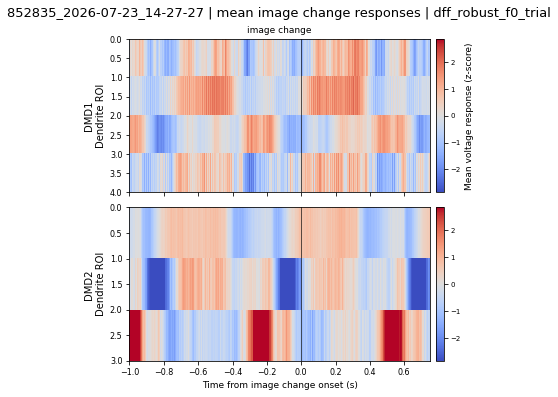

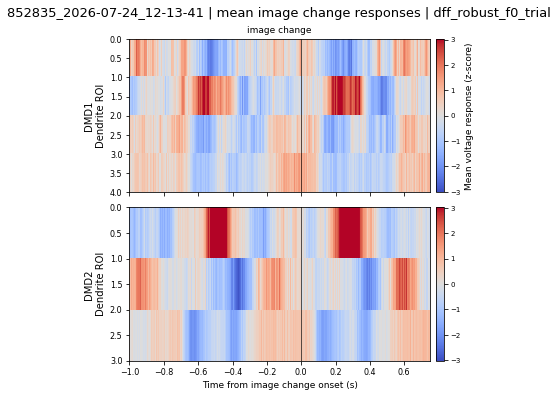

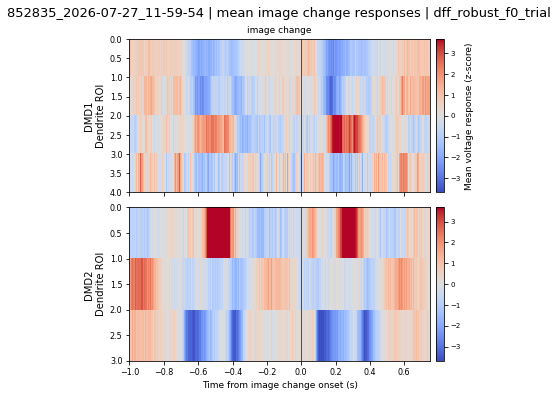

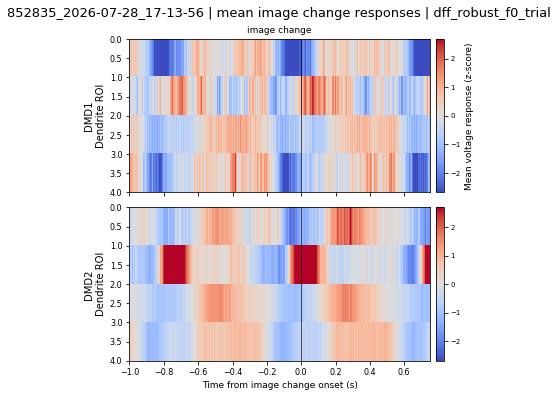

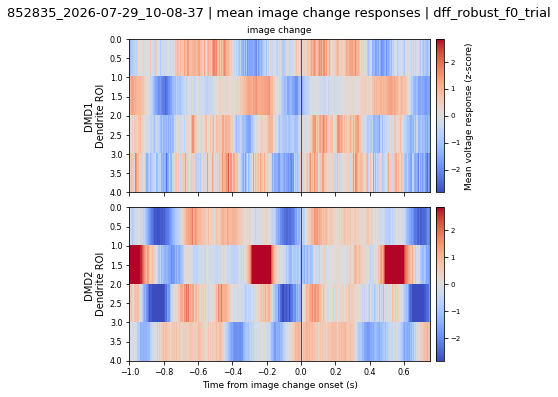

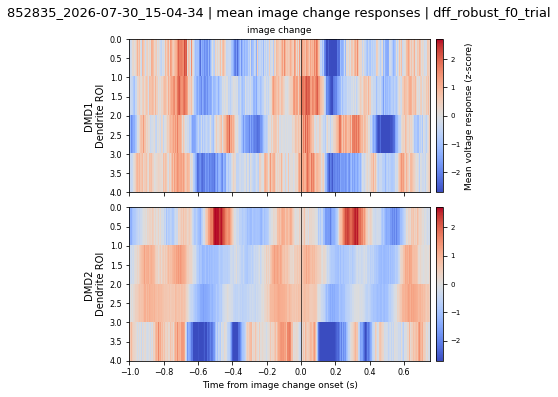

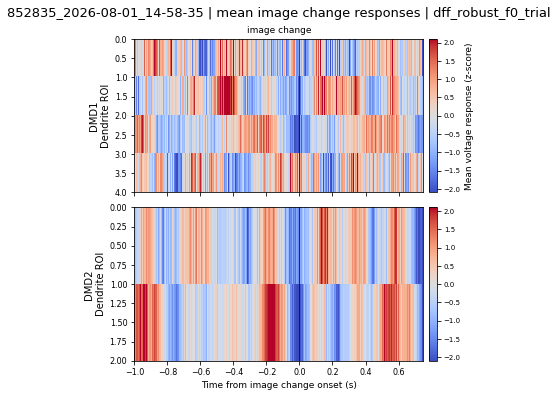

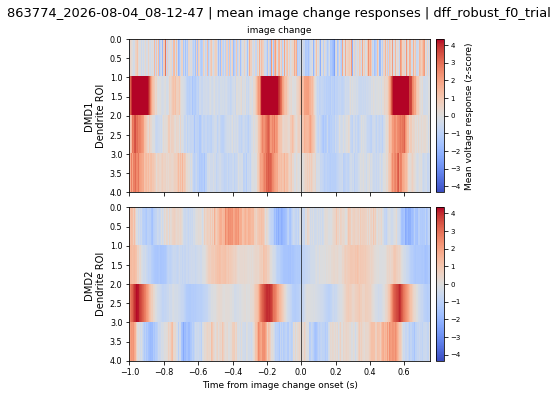

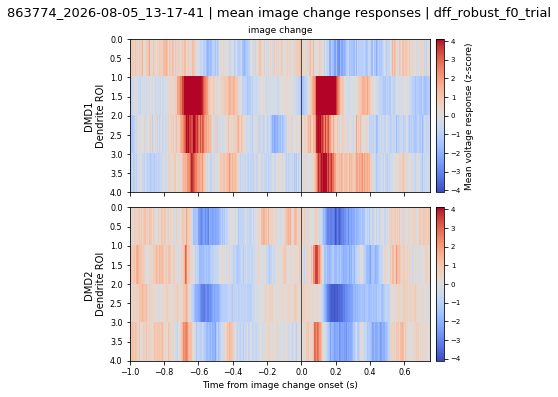

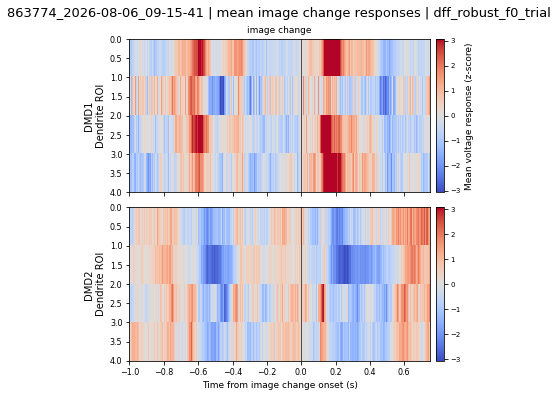

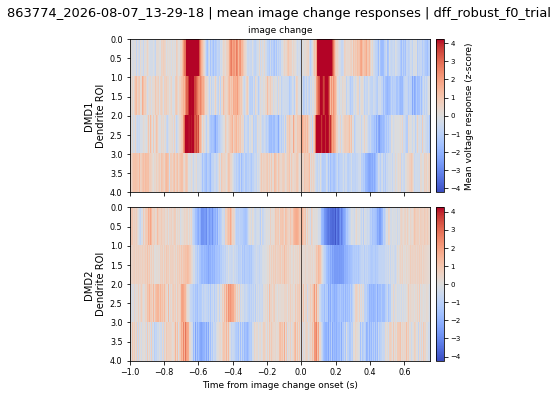

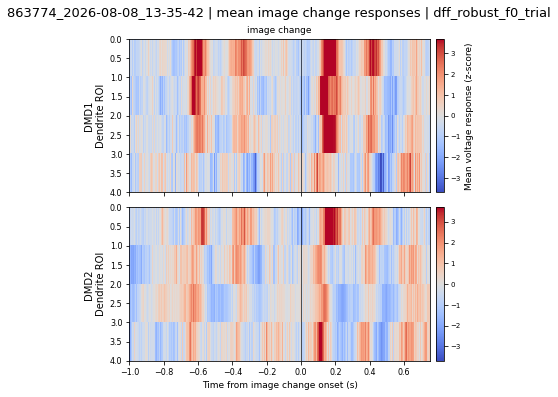

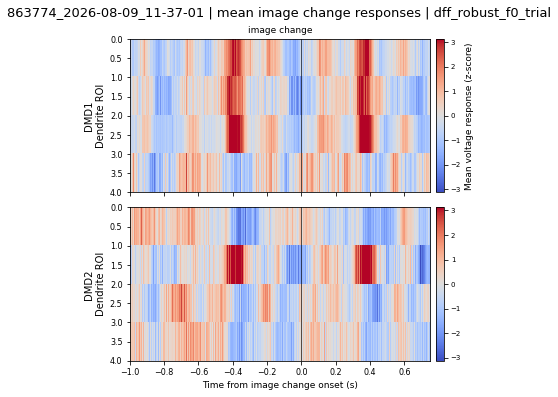

In [9]:
IMAGE_CHANGE_EVENT_KEYS = (
    "image_change",
    "image_changes",
    "change",
    "changes",
    "stimulus_change",
    "stimulus_changes",
)

IMAGE_CHANGE_TIMEBASE_KEYS = (
    "image_change",
    "change",
    "changes",
    "stimulus_change",
    "image",
)

plot_voltage_mean_event_grid_for_assets(
    assets,
    event_label="image change",
    event_key_candidates=IMAGE_CHANGE_EVENT_KEYS,
    timebase_key_candidates=IMAGE_CHANGE_TIMEBASE_KEYS,
    trace_variant=TRACE_VARIANT,
    dmds=dmds,
    use_roi_qc=True,
    normalize_rows=NORMALIZE_ROWS,
    baseline_subtract=BASELINE_SUBTRACT,
    baseline_window=BASELINE_WINDOW,
    smooth_sigma=SMOOTH_SIGMA,
    sort_by=SORT_BY,
    cmap=CMAP,
    percentiles=PERCENTILES,
    symmetric_clim=SYMMETRIC_CLIM,
    per_panel_colorbars=PER_PANEL_COLORBARS,
    save=False,  # set True when ready
)

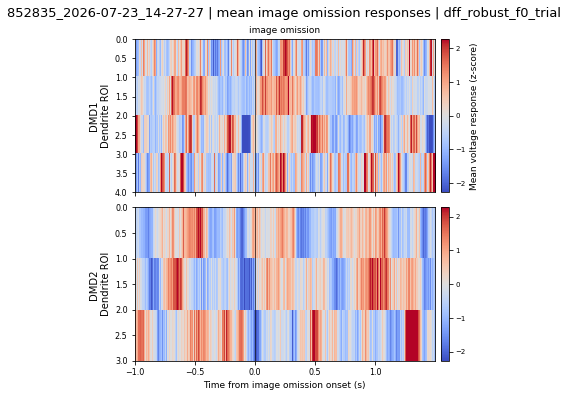

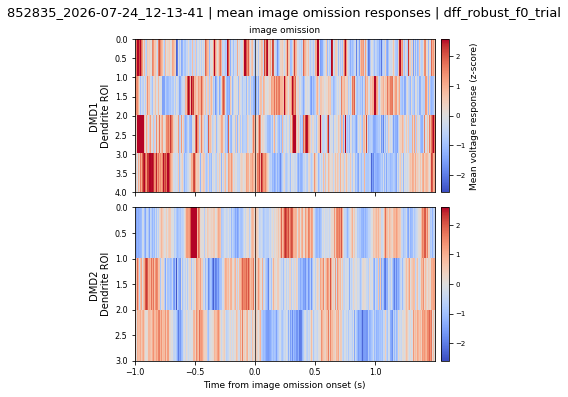

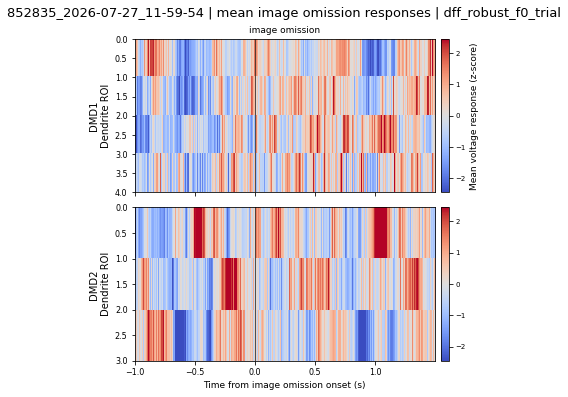

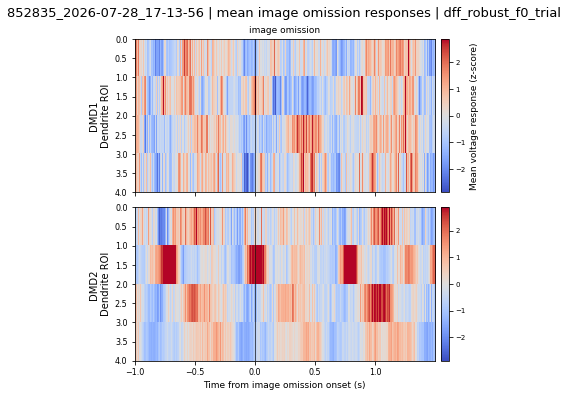

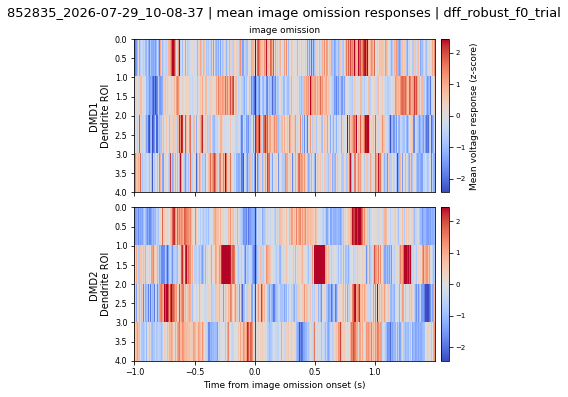

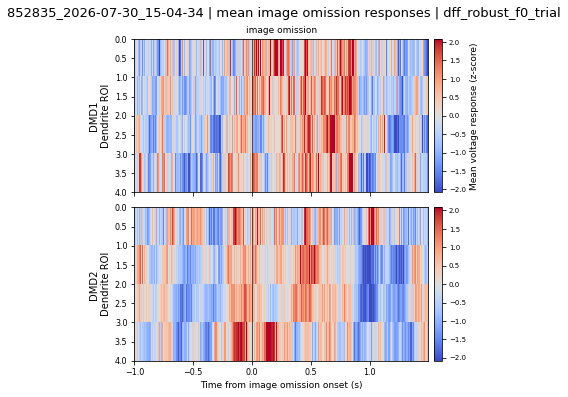

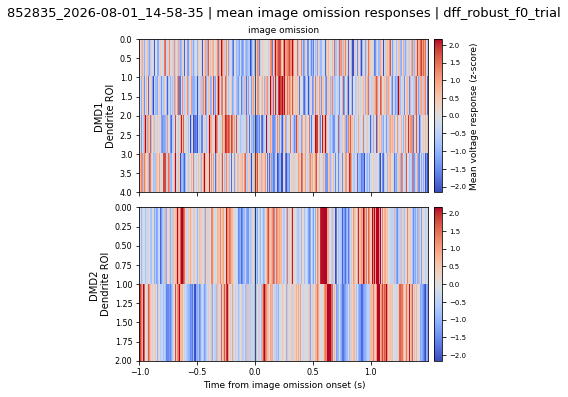

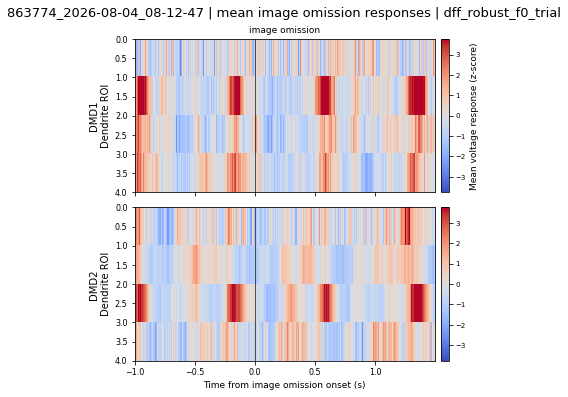

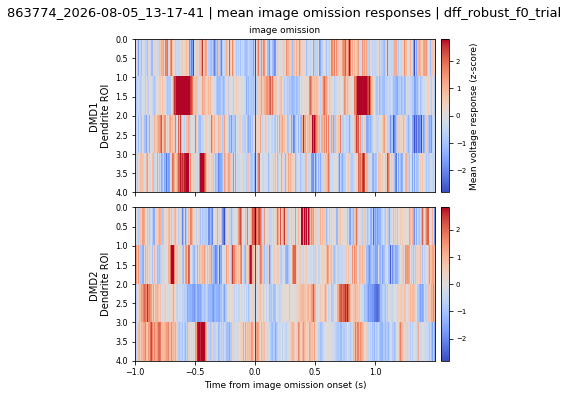

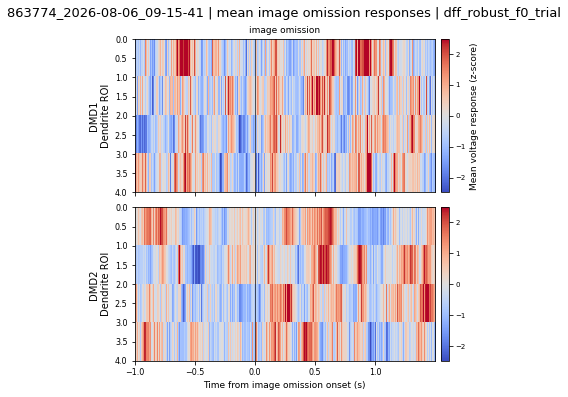

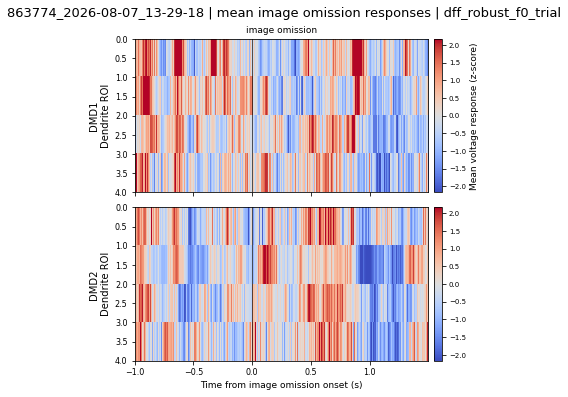

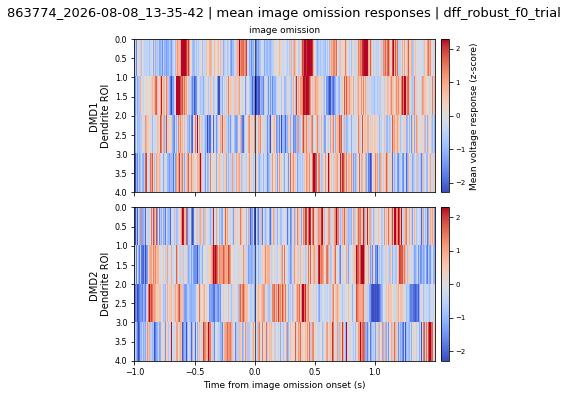

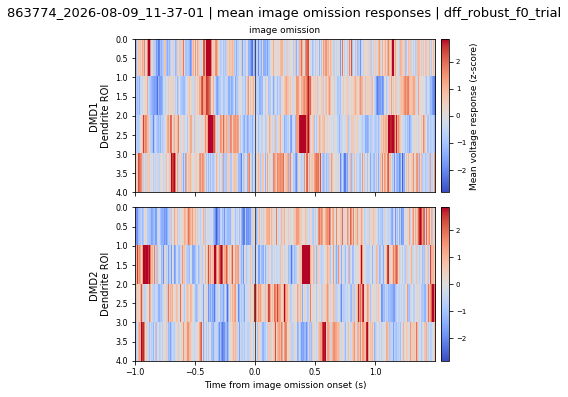

In [10]:
IMAGE_OMISSION_EVENT_KEYS = (
    "image_omission",
    "image_omissions",
    "omission",
    "omissions",
    "stimulus_omission",
    "stimulus_omissions",
)

IMAGE_OMISSION_TIMEBASE_KEYS = (
    "image_omission",
    "omission",
    "omissions",
    "stimulus_omission",
    "image",
)

plot_voltage_mean_event_grid_for_assets(
    assets,
    event_label="image omission",
    event_key_candidates=IMAGE_OMISSION_EVENT_KEYS,
    timebase_key_candidates=IMAGE_OMISSION_TIMEBASE_KEYS,
    trace_variant=TRACE_VARIANT,
    dmds=dmds,
    use_roi_qc=True,
    normalize_rows=NORMALIZE_ROWS,
    baseline_subtract=BASELINE_SUBTRACT,
    baseline_window=BASELINE_WINDOW,
    smooth_sigma=SMOOTH_SIGMA,
    sort_by=SORT_BY,
    cmap=CMAP,
    percentiles=PERCENTILES,
    symmetric_clim=SYMMETRIC_CLIM,
    per_panel_colorbars=PER_PANEL_COLORBARS,
    save=False,  # set True when ready
)

### Population average change/omission vectors

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from vip_slap2_analysis.voltage import analysis


# =============================================================================
# Population-vector plot settings
# =============================================================================

dmds = [1, 2]

NORMALIZE_ROWS = "zscore"
BASELINE_SUBTRACT = True
BASELINE_WINDOW = (-0.25, 0.0)
SMOOTH_SIGMA = 5

POP_ERROR = "sem"  # "sem" or "std"; computed across ROIs
USE_ROI_QC = True

FIGSIZE_PER_STIM = 4.0
FIG_HEIGHT = 3.8

SAVE_POP_FIGS = False


# =============================================================================
# Generic helpers
# =============================================================================

def _find_first_key(d, candidates):
    """Find first matching key, exact case-insensitive match first, substring match second."""
    if not isinstance(d, dict):
        return None

    keys = list(d.keys())
    lower_to_key = {str(k).lower(): k for k in keys}

    for cand in candidates:
        cand_l = str(cand).lower()
        if cand_l in lower_to_key:
            return lower_to_key[cand_l]

    for cand in candidates:
        cand_l = str(cand).lower()
        for key in keys:
            if cand_l in str(key).lower():
                return key

    return None


def _collect_mean_items(obj, prefix="", default_label="all", max_depth=4):
    """
    Recursively collect dicts/arrays containing a mean response matrix.

    Handles structures like:
        event_group["mean"]
        event_group[condition]["mean"]
        event_group["by_image"][image_name]["mean"]
    """
    items = []

    if isinstance(obj, np.ndarray):
        items.append((prefix or default_label, {"mean": obj}))
        return items

    if not isinstance(obj, dict):
        return items

    if "mean" in obj:
        items.append((prefix or default_label, obj))

    if max_depth <= 0:
        return items

    for key, val in obj.items():
        if key == "mean":
            continue
        if isinstance(val, dict):
            child_prefix = f"{prefix}: {key}" if prefix else str(key)
            items.extend(
                _collect_mean_items(
                    val,
                    prefix=child_prefix,
                    default_label=default_label,
                    max_depth=max_depth - 1,
                )
            )

    return items


def _get_event_timebase(pkg, item, timebase_key_candidates, fallback_to_image_timebase=True):
    """
    Find event timebase from item-local keys or pkg["timebase_sec"].

    Preference:
        1. item["timebase_sec"], item["time_sec"], item["t"], item["time"]
        2. pkg["timebase_sec"][event-specific key]
        3. pkg["timebase_sec"]["image"] fallback
    """
    for key in ("timebase_sec", "time_sec", "t", "time"):
        if isinstance(item, dict) and key in item:
            return np.asarray(item[key], dtype=float)

    tb = pkg.get("timebase_sec", None)

    if isinstance(tb, dict):
        for key in timebase_key_candidates:
            if key in tb:
                return np.asarray(tb[key], dtype=float)

        if fallback_to_image_timebase and "image" in tb:
            return np.asarray(tb["image"], dtype=float)

        if len(tb) == 1:
            return np.asarray(next(iter(tb.values())), dtype=float)

        raise KeyError(
            f"Could not find event timebase. Tried {timebase_key_candidates}. "
            f"Available timebase_sec keys: {list(tb.keys())}"
        )

    if tb is not None:
        return np.asarray(tb, dtype=float)

    raise KeyError("Could not find timebase_sec in mean NPZ package.")


def _prepare_mean_event_mat(
    pkg,
    dmd,
    item,
    t,
    *,
    use_roi_qc=True,
    normalize_rows="zscore",
    baseline_subtract=True,
    baseline_window=(-0.25, 0.0),
    smooth_sigma=5,
    context="event",
):
    """
    Return processed ROI x time matrix.

    Processing order:
        orient matrix -> ROI QC -> timebase coercion -> baseline subtraction
        -> row normalization -> smoothing
    """
    dmd_key = f"DMD{int(dmd)}"

    mat = np.asarray(item["mean"], dtype=float)
    t = np.asarray(t, dtype=float).reshape(-1)

    if mat.ndim != 2:
        raise ValueError(f"{context}: expected 2-D mean matrix, got shape {mat.shape}")

    # If stored as time x ROI, transpose to ROI x time.
    if t.size == mat.shape[0] and t.size != mat.shape[1]:
        mat = mat.T

    if use_roi_qc and "valid_rois_mask" in pkg[dmd_key]:
        mask = np.asarray(pkg[dmd_key]["valid_rois_mask"], dtype=bool).reshape(-1)

        if mask.size == mat.shape[0]:
            mat = mat[mask]
        elif mask.size == mat.shape[1]:
            mat = mat.T
            mat = mat[mask]
        else:
            print(
                f"Warning: {context}: valid_rois_mask length {mask.size} does not match "
                f"matrix shape {mat.shape}; plotting without ROI QC mask."
            )

    mat, t = analysis._coerce_event_mat_timebase(mat, t, context=context)

    if baseline_subtract:
        mat = analysis._baseline_subtract_mat(mat, t, baseline_window=baseline_window)

    if normalize_rows == "zscore":
        mat = analysis._robust_row_zscore(mat)
    elif normalize_rows in (None, False, "none"):
        pass
    else:
        raise ValueError("normalize_rows must be 'zscore', None, False, or 'none'.")

    mat = analysis._smooth_rows(mat, smooth_sigma)

    return mat, t


def _population_mean_and_error(mat, error="sem"):
    """
    Population summary across ROIs.

    mat is ROI x time.
    Error is across ROIs, not across trials.
    """
    mat = np.asarray(mat, dtype=float)

    pop_mean = np.nanmean(mat, axis=0)

    n = np.sum(np.isfinite(mat), axis=0)
    pop_std = np.nanstd(mat, axis=0, ddof=1)

    if error == "sem":
        pop_err = pop_std / np.sqrt(np.maximum(n, 1))
        pop_err[n <= 1] = np.nan
    elif error == "std":
        pop_err = pop_std
    else:
        raise ValueError("error must be 'sem' or 'std'.")

    return pop_mean, pop_err, n


def _clean_condition_label(label):
    """Clean stimulus/event condition names for subplot titles."""
    label = str(label)

    try:
        label = Path(label).stem
    except Exception:
        pass

    return (
        label
        .replace("_", " ")
        .replace(".png", "")
        .replace(".jpg", "")
        .replace(".tif", "")
        .replace(".tiff", "")
    )


def _maybe_drop_aggregate_condition(condition_labels, event_label):
    """
    If there are subconditions plus a top-level aggregate, drop the aggregate panel.
    Keeps aggregate if it is the only available condition.
    """
    if len(condition_labels) <= 1:
        return condition_labels

    aggregate_names = {
        "",
        "all",
        event_label,
        event_label.replace(" ", "_"),
        event_label.replace(" ", "-"),
    }
    aggregate_names = {x.lower() for x in aggregate_names}

    kept = [
        x for x in condition_labels
        if str(x).lower() not in aggregate_names
    ]

    return kept if len(kept) > 0 else condition_labels


# =============================================================================
# Stimulus timing annotations
# =============================================================================

def _add_stimulus_timing_annotations(ax, event_label):
    """
    Add passive DoC stimulus timing annotations.

    Change-aligned plots:
        previous flash: -0.75 to -0.50 s
        change flash:    0.00 to  0.25 s

    Omission-aligned plots:
        previous flash: -0.75 to -0.50 s
        next flash:      0.75 to  1.00 s
        omitted flash window: dashed lines at 0.00 and 0.25 s
    """
    event_l = str(event_label).lower()

    span_kwargs = dict(
        color="k",
        alpha=0.08,
        linewidth=0,
        zorder=0,
    )

    dashed_line_kwargs = dict(
        color="k",
        linestyle="--",
        linewidth=0.9,
        alpha=0.65,
        zorder=1,
    )

    if "omission" in event_l or "omit" in event_l:
        ax.axvspan(-0.75, -0.50, **span_kwargs)
        ax.axvspan(0.75, 1.00, **span_kwargs)

        # Dashed omitted-flash window.
        ax.axvline(0.00, **dashed_line_kwargs)
        ax.axvline(0.25, **dashed_line_kwargs)

    elif "change" in event_l:
        ax.axvspan(-0.75, -0.50, **span_kwargs)
        ax.axvspan(0.00, 0.25, **span_kwargs)


# =============================================================================
# Main plotting function
# =============================================================================

def plot_population_vectors_for_event(
    assets,
    *,
    event_label,
    event_key_candidates,
    timebase_key_candidates,
    trace_variant=TRACE_VARIANT,
    dmds=(1, 2),
    use_roi_qc=True,
    normalize_rows="zscore",
    baseline_subtract=True,
    baseline_window=(-0.25, 0.0),
    smooth_sigma=5,
    pop_error="sem",
    drop_aggregate_when_subconditions=True,
    save=False,
):
    """
    For each session, make one population-vector figure for one event class.

    Output:
        One figure per session per event_label.

    Figure organization:
        columns = stimulus type / event subcondition
        lines   = DMD1 and DMD2 population average responses
        error   = fill_between ± SEM or ± STD across ROIs
    """
    event_slug = (
        event_label
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

    for asset in assets:
        session_id = getattr(asset, "session_id", "session")

        try:
            pkg, mean_path = analysis.load_voltage_mean_npz(
                asset,
                trace_variant=trace_variant,
                mean_npz=None,
            )
        except FileNotFoundError as e:
            print(f"{session_id}: {e}")
            continue

        panel_data = {}
        condition_labels = []

        for dmd in dmds:
            dmd_key = f"DMD{int(dmd)}"

            if dmd_key not in pkg:
                print(f"{session_id}: {dmd_key} not found in {mean_path}")
                continue

            event_key = _find_first_key(pkg[dmd_key], event_key_candidates)

            if event_key is None:
                print(
                    f"{session_id} | {dmd_key}: no {event_label} group found. "
                    f"Tried {event_key_candidates}. "
                    f"Available keys: {list(pkg[dmd_key].keys())}"
                )
                continue

            event_items = _collect_mean_items(
                pkg[dmd_key][event_key],
                prefix="",
                default_label=event_label,
                max_depth=4,
            )

            if len(event_items) == 0:
                print(f"{session_id} | {dmd_key}: found {event_key}, but no mean matrices.")
                continue

            for condition_label, item in event_items:
                condition_label = str(condition_label)

                try:
                    t = _get_event_timebase(
                        pkg,
                        item,
                        timebase_key_candidates=timebase_key_candidates,
                        fallback_to_image_timebase=True,
                    )

                    mat, t = _prepare_mean_event_mat(
                        pkg,
                        dmd,
                        item,
                        t,
                        use_roi_qc=use_roi_qc,
                        normalize_rows=normalize_rows,
                        baseline_subtract=baseline_subtract,
                        baseline_window=baseline_window,
                        smooth_sigma=smooth_sigma,
                        context=f"{session_id}/{dmd_key}/{event_key}/{condition_label}",
                    )

                    pop_mean, pop_err, n_per_time = _population_mean_and_error(
                        mat,
                        error=pop_error,
                    )

                    panel_data[(dmd, condition_label)] = {
                        "t": t,
                        "mean": pop_mean,
                        "err": pop_err,
                        "n_rois": int(np.nanmax(n_per_time)),
                        "event_key": event_key,
                    }

                    if condition_label not in condition_labels:
                        condition_labels.append(condition_label)

                except (KeyError, ValueError) as e:
                    print(f"{session_id} | {dmd_key} | {condition_label} failed: {e}")

        if len(panel_data) == 0 or len(condition_labels) == 0:
            print(f"{session_id}: no {event_label} population vectors could be plotted; skipping.")
            continue

        if drop_aggregate_when_subconditions:
            condition_labels = _maybe_drop_aggregate_condition(condition_labels, event_label)

        n_cols = len(condition_labels)
        fig_w = max(FIGSIZE_PER_STIM * n_cols, 5.5)

        fig, axes = plt.subplots(
            1,
            n_cols,
            figsize=(fig_w, FIG_HEIGHT),
            sharex=True,
            sharey=True,
            squeeze=False,
            constrained_layout=True,
        )
        axes = axes.ravel()

        for col_idx, condition_label in enumerate(condition_labels):
            ax = axes[col_idx]

            # Put timing annotations behind the data.
            _add_stimulus_timing_annotations(ax, event_label)

            for dmd in dmds:
                item = panel_data.get((dmd, condition_label), None)

                if item is None:
                    continue

                t = item["t"]
                y = item["mean"]
                err = item["err"]
                n_rois = item["n_rois"]

                line, = ax.plot(
                    t,
                    y,
                    lw=1.8,
                    label=f"DMD{dmd} (n={n_rois} ROIs)",
                    zorder=3,
                )

                ax.fill_between(
                    t,
                    y - err,
                    y + err,
                    color=line.get_color(),
                    alpha=0.22,
                    linewidth=0,
                    zorder=2,
                )

            # Solid alignment line for change plots only.
            # Omission plots already have dashed lines marking the omitted flash window.
            if "omission" not in str(event_label).lower() and "omit" not in str(event_label).lower():
                ax.axvline(0, color="k", lw=0.8, alpha=0.8, zorder=2)

            ax.axhline(0, color="k", lw=0.6, alpha=0.35, zorder=1)

            ax.set_title(_clean_condition_label(condition_label), fontsize=10)
            ax.set_xlabel(f"Time from {event_label} onset (s)", fontsize=10)
            ax.tick_params(axis="both", which="major", labelsize=9)

            if col_idx == 0:
                if normalize_rows == "zscore":
                    ax.set_ylabel(f"Population mean response\nROI z-score ± {pop_error}", fontsize=10)
                else:
                    ax.set_ylabel(f"Population mean response\n± {pop_error}", fontsize=10)

            ax.legend(frameon=False, fontsize=8)

        fig.suptitle(
            f"{session_id} | population average {event_label} responses | {trace_variant}",
            fontsize=13,
        )
        fig.patch.set_alpha(0)

        SAVE_PATH.mkdir(parents=True, exist_ok=True)
        filen = f"{today_str}_{session_id}_population_{event_slug}_responses"

        if save:
            try:
                save_figure(fig, str(SAVE_PATH / filen), formats=[".pdf"], dpi=300)
            except NameError:
                fig.savefig(SAVE_PATH / f"{filen}.pdf", dpi=300, bbox_inches="tight")

        plt.show()


# =============================================================================
# Event definitions
# =============================================================================

IMAGE_CHANGE_EVENT_KEYS = (
    "image_change",
    "image_changes",
    "change",
    "changes",
    "stimulus_change",
    "stimulus_changes",
)

IMAGE_CHANGE_TIMEBASE_KEYS = (
    "image_change",
    "image_changes",
    "change",
    "changes",
    "stimulus_change",
    "stimulus_changes",
    "image",
)

IMAGE_OMISSION_EVENT_KEYS = (
    "image_omission",
    "image_omissions",
    "omission",
    "omissions",
    "stimulus_omission",
    "stimulus_omissions",
)

IMAGE_OMISSION_TIMEBASE_KEYS = (
    "image_omission",
    "image_omissions",
    "omission",
    "omissions",
    "stimulus_omission",
    "stimulus_omissions",
    "image",
)


# =============================================================================
# Generate figures
# =============================================================================

# One change-response population vector figure per session.
plot_population_vectors_for_event(
    assets,
    event_label="change",
    event_key_candidates=IMAGE_CHANGE_EVENT_KEYS,
    timebase_key_candidates=IMAGE_CHANGE_TIMEBASE_KEYS,
    trace_variant=TRACE_VARIANT,
    dmds=dmds,
    use_roi_qc=USE_ROI_QC,
    normalize_rows=NORMALIZE_ROWS,
    baseline_subtract=BASELINE_SUBTRACT,
    baseline_window=BASELINE_WINDOW,
    smooth_sigma=SMOOTH_SIGMA,
    pop_error=POP_ERROR,
    save=SAVE_POP_FIGS,
)

# One omission-response population vector figure per session.
plot_population_vectors_for_event(
    assets,
    event_label="omission",
    event_key_candidates=IMAGE_OMISSION_EVENT_KEYS,
    timebase_key_candidates=IMAGE_OMISSION_TIMEBASE_KEYS,
    trace_variant=TRACE_VARIANT,
    dmds=dmds,
    use_roi_qc=USE_ROI_QC,
    normalize_rows=NORMALIZE_ROWS,
    baseline_subtract=BASELINE_SUBTRACT,
    baseline_window=BASELINE_WINDOW,
    smooth_sigma=SMOOTH_SIGMA,
    pop_error=POP_ERROR,
    save=SAVE_POP_FIGS,
)

### Quantify image/change/omission dynamics per DMD across days

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from vip_slap2_analysis.voltage import analysis


# =============================================================================
# User-editable configuration
# =============================================================================

dmds = [1, 2]

# Main response preprocessing.
# For dynamics: use "zscore".
# For amplitude-preserving analysis: set NORMALIZE_ROWS = None.
NORMALIZE_ROWS = "zscore"
BASELINE_SUBTRACT = True
BASELINE_WINDOW = (-0.25, 0.0)
SMOOTH_SIGMA = 5
USE_ROI_QC = True

# Optional manual experiment-type overrides.
# Fill this if experiment_type is not automatically found from asset/process_df.
# Keys can be session_id strings.
EXPERIMENT_TYPE_BY_SESSION = {
    # "826031_2026-02-02_10-00-00": "familiar",
    # "826031_2026-02-03_10-00-00": "novel",
    # "826031_2026-02-04_10-00-00": "novel+",
}

EXPERIMENT_TYPE_ORDER = ["familiar", "novel", "novel+", "unknown"]

# Time bin definitions.
EVENT_BINS = {
    "change": {
        "prev_flash": (-0.75, -0.50),
        "pre_change_baseline": (-0.25, 0.00),
        "change_flash": (0.00, 0.25),
        "early_post_change": (0.25, 0.50),
        "late_post_change": (0.50, 0.75),
        "next_flash": (0.75, 1.00),
    },
    "omission": {
        "prev_flash": (-0.75, -0.50),
        "pre_omission_baseline": (-0.25, 0.00),
        "omission_window": (0.00, 0.25),
        "early_post_omission": (0.25, 0.50),
        "late_post_omission": (0.50, 0.75),
        "next_flash": (0.75, 1.00),
    },
}

IMAGE_CHANGE_EVENT_KEYS = (
    "image_change",
    "image_changes",
    "change",
    "changes",
    "stimulus_change",
    "stimulus_changes",
)

IMAGE_CHANGE_TIMEBASE_KEYS = (
    "image_change",
    "image_changes",
    "change",
    "changes",
    "stimulus_change",
    "stimulus_changes",
    "image",
)

IMAGE_OMISSION_EVENT_KEYS = (
    "image_omission",
    "image_omissions",
    "omission",
    "omissions",
    "stimulus_omission",
    "stimulus_omissions",
)

IMAGE_OMISSION_TIMEBASE_KEYS = (
    "image_omission",
    "image_omissions",
    "omission",
    "omissions",
    "stimulus_omission",
    "stimulus_omissions",
    "image",
)


# =============================================================================
# Metadata helpers
# =============================================================================

def _normalize_experiment_type(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "unknown"

    s = str(x).strip().lower()
    s = s.replace("_", " ").replace("-", " ")

    if s in {"", "none", "nan"}:
        return "unknown"

    if "novel+" in s or "novel plus" in s or "novelplus" in s or "novel +" in s:
        return "novel+"
    if "novel" in s:
        return "novel"
    if "familiar" in s or "familair" in s or re.search(r"\bfam\b", s):
        return "familiar"

    return str(x)


def _get_attr_first(obj, names, default=None):
    for name in names:
        if hasattr(obj, name):
            val = getattr(obj, name)
            if val is not None:
                return val
    return default


def _lookup_process_df_row(asset, process_df=None):
    if process_df is None:
        return None

    session_id = str(getattr(asset, "session_id", ""))
    if session_id == "":
        return None

    candidate_cols = [
        "session_id",
        "ophys_session_id",
        "session",
        "session_name",
        "asset_id",
    ]

    for col in candidate_cols:
        if col in process_df.columns:
            hits = process_df[process_df[col].astype(str) == session_id]
            if len(hits) > 0:
                return hits.iloc[0]

    # Fallback: search all object/string-like columns for exact session_id.
    for col in process_df.columns:
        try:
            hits = process_df[process_df[col].astype(str) == session_id]
            if len(hits) > 0:
                return hits.iloc[0]
        except Exception:
            pass

    return None


def _infer_mouse_id(asset, row=None):
    val = _get_attr_first(
        asset,
        ["mouse_id", "subject_id", "specimen_id", "animal_id", "external_specimen_id"],
        default=None,
    )

    if val is not None:
        return str(val)

    if row is not None:
        for col in ["mouse_id", "subject_id", "specimen_id", "animal_id", "external_specimen_id"]:
            if col in row.index and pd.notna(row[col]):
                return str(row[col])

    session_id = str(getattr(asset, "session_id", ""))
    if "_" in session_id:
        return session_id.split("_")[0]

    return "unknown"


def _infer_experiment_type(asset, row=None, override=None):
    session_id = str(getattr(asset, "session_id", ""))

    if override is not None and session_id in override:
        return _normalize_experiment_type(override[session_id])

    attr_val = _get_attr_first(
        asset,
        [
            "experiment_type",
            "experience_level",
            "session_type",
            "stimulus_set",
            "image_set",
            "protocol",
            "paradigm",
        ],
        default=None,
    )

    if attr_val is not None:
        return _normalize_experiment_type(attr_val)

    if row is not None:
        candidate_cols = [
            "experiment_type",
            "experience_level",
            "session_type",
            "stimulus_set",
            "image_set",
            "protocol",
            "paradigm",
            "passive_context",
        ]

        for col in candidate_cols:
            if col in row.index and pd.notna(row[col]):
                val = _normalize_experiment_type(row[col])
                if val != "unknown":
                    return val

    return "unknown"


# =============================================================================
# Mean NPZ/event helpers
# =============================================================================

def _find_first_key(d, candidates):
    if not isinstance(d, dict):
        return None

    keys = list(d.keys())
    lower_to_key = {str(k).lower(): k for k in keys}

    for cand in candidates:
        cand_l = str(cand).lower()
        if cand_l in lower_to_key:
            return lower_to_key[cand_l]

    for cand in candidates:
        cand_l = str(cand).lower()
        for key in keys:
            if cand_l in str(key).lower():
                return key

    return None


def _collect_mean_items(obj, prefix="", default_label="all", max_depth=4):
    """
    Recursively collect objects containing a mean response matrix.

    Handles:
        event_group["mean"]
        event_group[condition]["mean"]
        event_group["by_image"][image_name]["mean"]
    """
    items = []

    if isinstance(obj, np.ndarray):
        items.append((prefix or default_label, {"mean": obj}))
        return items

    if not isinstance(obj, dict):
        return items

    if "mean" in obj:
        items.append((prefix or default_label, obj))

    if max_depth <= 0:
        return items

    for key, val in obj.items():
        if key == "mean":
            continue
        if isinstance(val, dict):
            child_prefix = f"{prefix}: {key}" if prefix else str(key)
            items.extend(
                _collect_mean_items(
                    val,
                    prefix=child_prefix,
                    default_label=default_label,
                    max_depth=max_depth - 1,
                )
            )

    return items


def _get_event_timebase(pkg, item, timebase_key_candidates, fallback_to_image_timebase=True):
    for key in ("timebase_sec", "time_sec", "t", "time"):
        if isinstance(item, dict) and key in item:
            return np.asarray(item[key], dtype=float)

    tb = pkg.get("timebase_sec", None)

    if isinstance(tb, dict):
        for key in timebase_key_candidates:
            if key in tb:
                return np.asarray(tb[key], dtype=float)

        if fallback_to_image_timebase and "image" in tb:
            return np.asarray(tb["image"], dtype=float)

        if len(tb) == 1:
            return np.asarray(next(iter(tb.values())), dtype=float)

        raise KeyError(
            f"Could not find event timebase. Tried {timebase_key_candidates}. "
            f"Available timebase_sec keys: {list(tb.keys())}"
        )

    if tb is not None:
        return np.asarray(tb, dtype=float)

    raise KeyError("Could not find timebase_sec in mean NPZ package.")


def _prepare_mean_event_mat(
    pkg,
    dmd,
    item,
    t,
    *,
    use_roi_qc=True,
    normalize_rows="zscore",
    baseline_subtract=True,
    baseline_window=(-0.25, 0.0),
    smooth_sigma=5,
    context="event",
):
    dmd_key = f"DMD{int(dmd)}"

    mat = np.asarray(item["mean"], dtype=float)
    t = np.asarray(t, dtype=float).reshape(-1)

    if mat.ndim != 2:
        raise ValueError(f"{context}: expected 2-D mean matrix, got shape {mat.shape}")

    # Orient as ROI x time.
    if t.size == mat.shape[0] and t.size != mat.shape[1]:
        mat = mat.T

    if use_roi_qc and "valid_rois_mask" in pkg[dmd_key]:
        mask = np.asarray(pkg[dmd_key]["valid_rois_mask"], dtype=bool).reshape(-1)

        if mask.size == mat.shape[0]:
            mat = mat[mask]
        elif mask.size == mat.shape[1]:
            mat = mat.T
            mat = mat[mask]
#         else:
#             print(
#                 f"Warning: {context}: valid_rois_mask length {mask.size} does not match "
#                 f"matrix shape {mat.shape}; plotting without ROI QC mask."
#             )

    mat, t = analysis._coerce_event_mat_timebase(mat, t, context=context)

    if baseline_subtract:
        mat = analysis._baseline_subtract_mat(mat, t, baseline_window=baseline_window)

    if normalize_rows == "zscore":
        mat = analysis._robust_row_zscore(mat)
    elif normalize_rows in (None, False, "none"):
        pass
    else:
        raise ValueError("normalize_rows must be 'zscore', None, False, or 'none'.")

    mat = analysis._smooth_rows(mat, smooth_sigma)

    return mat, t


def _safe_window_mask(t, window):
    start, stop = window
    return (t >= start) & (t < stop)


def _compute_roi_bin_metrics(mat, t, event_type, bins):
    """
    Compute bin means per ROI.

    Returns long-form rows:
        roi_idx, metric, value, window_start, window_stop
    """
    rows = []
    mat = np.asarray(mat, dtype=float)
    t = np.asarray(t, dtype=float)

    # First compute direct bin means.
    bin_values = {}

    for bin_name, window in bins.items():
        mask = _safe_window_mask(t, window)

        if not np.any(mask):
            vals = np.full(mat.shape[0], np.nan)
        else:
            vals = np.nanmean(mat[:, mask], axis=1)

        bin_values[bin_name] = vals

        for roi_idx, val in enumerate(vals):
            rows.append(
                {
                    "roi_idx": roi_idx,
                    "metric": bin_name,
                    "value": val,
                    "window_start": window[0],
                    "window_stop": window[1],
                    "metric_class": "bin_mean",
                }
            )

    # Then compute derived response metrics.
    derived = {}

    if event_type == "change":
        pre = bin_values.get("pre_change_baseline", np.nan)
        derived["change_flash_minus_baseline"] = bin_values.get("change_flash", np.nan) - pre
        derived["post_change_minus_baseline"] = (
            0.5 * bin_values.get("early_post_change", np.nan)
            + 0.5 * bin_values.get("late_post_change", np.nan)
            - pre
        )
        derived["change_vs_prev_flash"] = (
            bin_values.get("change_flash", np.nan)
            - bin_values.get("prev_flash", np.nan)
        )
        derived["sustained_index_change"] = (
            bin_values.get("late_post_change", np.nan)
            - bin_values.get("change_flash", np.nan)
        )

    elif event_type == "omission":
        pre = bin_values.get("pre_omission_baseline", np.nan)
        derived["omission_window_minus_baseline"] = bin_values.get("omission_window", np.nan) - pre
        derived["post_omission_minus_baseline"] = (
            0.5 * bin_values.get("early_post_omission", np.nan)
            + 0.5 * bin_values.get("late_post_omission", np.nan)
            - pre
        )
        derived["omission_vs_prev_flash"] = (
            bin_values.get("omission_window", np.nan)
            - bin_values.get("prev_flash", np.nan)
        )
        derived["rebound_to_next_flash"] = (
            bin_values.get("next_flash", np.nan)
            - bin_values.get("omission_window", np.nan)
        )

    for metric_name, vals in derived.items():
        vals = np.asarray(vals, dtype=float)

        for roi_idx, val in enumerate(vals):
            rows.append(
                {
                    "roi_idx": roi_idx,
                    "metric": metric_name,
                    "value": val,
                    "window_start": np.nan,
                    "window_stop": np.nan,
                    "metric_class": "derived",
                }
            )

    return rows


def _population_mean_and_error(mat, error="sem"):
    mat = np.asarray(mat, dtype=float)
    y = np.nanmean(mat, axis=0)
    n = np.sum(np.isfinite(mat), axis=0)
    sd = np.nanstd(mat, axis=0, ddof=1)

    if error == "sem":
        err = sd / np.sqrt(np.maximum(n, 1))
        err[n <= 1] = np.nan
    elif error == "std":
        err = sd
    else:
        raise ValueError("error must be 'sem' or 'std'.")

    return y, err, n


def _extract_one_event_type(
    asset,
    pkg,
    *,
    event_type,
    event_key_candidates,
    timebase_key_candidates,
    session_id,
    mouse_id,
    experiment_type,
    trace_variant,
    dmds=(1, 2),
    use_roi_qc=True,
    normalize_rows="zscore",
    baseline_subtract=True,
    baseline_window=(-0.25, 0.0),
    smooth_sigma=5,
):
    roi_metric_rows = []
    trace_rows = []

    bins = EVENT_BINS[event_type]

    for dmd in dmds:
        dmd_key = f"DMD{int(dmd)}"

        if dmd_key not in pkg:
            print(f"{session_id}: {dmd_key} not found.")
            continue

        event_key = _find_first_key(pkg[dmd_key], event_key_candidates)

        if event_key is None:
            print(
                f"{session_id} | {dmd_key}: no {event_type} group found. "
                f"Tried {event_key_candidates}. Available keys: {list(pkg[dmd_key].keys())}"
            )
            continue

        event_items = _collect_mean_items(
            pkg[dmd_key][event_key],
            prefix="",
            default_label=event_type,
            max_depth=4,
        )

        if len(event_items) == 0:
            print(f"{session_id} | {dmd_key}: found {event_key}, but no mean matrices.")
            continue

        for condition_label, item in event_items:
            condition_label = str(condition_label)

            try:
                t = _get_event_timebase(
                    pkg,
                    item,
                    timebase_key_candidates=timebase_key_candidates,
                    fallback_to_image_timebase=True,
                )

                mat, t = _prepare_mean_event_mat(
                    pkg,
                    dmd,
                    item,
                    t,
                    use_roi_qc=use_roi_qc,
                    normalize_rows=normalize_rows,
                    baseline_subtract=baseline_subtract,
                    baseline_window=baseline_window,
                    smooth_sigma=smooth_sigma,
                    context=f"{session_id}/{dmd_key}/{event_key}/{condition_label}",
                )

                # ROI bin metrics.
                rows = _compute_roi_bin_metrics(
                    mat,
                    t,
                    event_type=event_type,
                    bins=bins,
                )

                for r in rows:
                    r.update(
                        {
                            "mouse_id": mouse_id,
                            "session_id": session_id,
                            "experiment_type": experiment_type,
                            "trace_variant": trace_variant,
                            "event_type": event_type,
                            "condition": condition_label,
                            "dmd": int(dmd),
                            "n_rois_in_matrix": int(mat.shape[0]),
                        }
                    )
                    roi_metric_rows.append(r)

                # Population trace for pooled plotting.
                pop_mean, pop_err, n_per_time = _population_mean_and_error(mat, error="sem")

                for sample_idx, (tt, yy, ee, nn) in enumerate(zip(t, pop_mean, pop_err, n_per_time)):
                    trace_rows.append(
                        {
                            "mouse_id": mouse_id,
                            "session_id": session_id,
                            "experiment_type": experiment_type,
                            "trace_variant": trace_variant,
                            "event_type": event_type,
                            "condition": condition_label,
                            "dmd": int(dmd),
                            "sample_idx": sample_idx,
                            "time_sec": float(tt),
                            "pop_mean": float(yy),
                            "pop_sem_across_rois": float(ee) if np.isfinite(ee) else np.nan,
                            "n_rois": int(np.nanmax(n_per_time)),
                        }
                    )

            except (KeyError, ValueError) as e:
                print(f"{session_id} | {dmd_key} | {event_type} | {condition_label} failed: {e}")

    return roi_metric_rows, trace_rows


def extract_event_dynamics_for_assets(
    assets,
    *,
    process_df=None,
    trace_variant=TRACE_VARIANT,
    dmds=(1, 2),
    use_roi_qc=True,
    normalize_rows="zscore",
    baseline_subtract=True,
    baseline_window=(-0.25, 0.0),
    smooth_sigma=5,
    experiment_type_by_session=None,
):
    """
    Extract ROI-level bin metrics, session/DMD summaries, and population traces.

    Returns:
        roi_metric_df:
            one row per ROI x metric x session x DMD x event x condition

        session_metric_df:
            one row per session x DMD x event x condition x metric,
            averaged across ROIs

        pop_trace_df:
            one row per session x DMD x event x condition x time
    """
    roi_metric_rows = []
    trace_rows = []

    for asset in assets:
        session_id = str(getattr(asset, "session_id", "session"))
        row = _lookup_process_df_row(asset, process_df=process_df)
        mouse_id = _infer_mouse_id(asset, row=row)
        experiment_type = _infer_experiment_type(
            asset,
            row=row,
            override=experiment_type_by_session,
        )

        try:
            pkg, mean_path = analysis.load_voltage_mean_npz(
                asset,
                trace_variant=trace_variant,
                mean_npz=None,
            )
        except FileNotFoundError as e:
            print(f"{session_id}: {e}")
            continue

        # Changes.
        rows, traces = _extract_one_event_type(
            asset,
            pkg,
            event_type="change",
            event_key_candidates=IMAGE_CHANGE_EVENT_KEYS,
            timebase_key_candidates=IMAGE_CHANGE_TIMEBASE_KEYS,
            session_id=session_id,
            mouse_id=mouse_id,
            experiment_type=experiment_type,
            trace_variant=trace_variant,
            dmds=dmds,
            use_roi_qc=use_roi_qc,
            normalize_rows=normalize_rows,
            baseline_subtract=baseline_subtract,
            baseline_window=baseline_window,
            smooth_sigma=smooth_sigma,
        )
        roi_metric_rows.extend(rows)
        trace_rows.extend(traces)

        # Omissions.
        rows, traces = _extract_one_event_type(
            asset,
            pkg,
            event_type="omission",
            event_key_candidates=IMAGE_OMISSION_EVENT_KEYS,
            timebase_key_candidates=IMAGE_OMISSION_TIMEBASE_KEYS,
            session_id=session_id,
            mouse_id=mouse_id,
            experiment_type=experiment_type,
            trace_variant=trace_variant,
            dmds=dmds,
            use_roi_qc=use_roi_qc,
            normalize_rows=normalize_rows,
            baseline_subtract=baseline_subtract,
            baseline_window=baseline_window,
            smooth_sigma=smooth_sigma,
        )
        roi_metric_rows.extend(rows)
        trace_rows.extend(traces)

    roi_metric_df = pd.DataFrame(roi_metric_rows)
    pop_trace_df = pd.DataFrame(trace_rows)

    if len(roi_metric_df) == 0:
        session_metric_df = pd.DataFrame()
    else:
        group_cols = [
            "mouse_id",
            "session_id",
            "experiment_type",
            "trace_variant",
            "event_type",
            "condition",
            "dmd",
            "metric",
            "metric_class",
        ]

        session_metric_df = (
            roi_metric_df
            .groupby(group_cols, dropna=False)
            .agg(
                value=("value", "mean"),
                sd_across_rois=("value", "std"),
                n_rois=("value", lambda x: int(np.sum(np.isfinite(x)))),
                window_start=("window_start", "first"),
                window_stop=("window_stop", "first"),
            )
            .reset_index()
        )

        session_metric_df["sem_across_rois"] = (
            session_metric_df["sd_across_rois"]
            / np.sqrt(session_metric_df["n_rois"].clip(lower=1))
        )
        session_metric_df.loc[session_metric_df["n_rois"] <= 1, "sem_across_rois"] = np.nan

    return roi_metric_df, session_metric_df, pop_trace_df


def _add_stimulus_timing_annotations(ax, event_type):
    span_kwargs = dict(color="k", alpha=0.08, linewidth=0, zorder=0)
    dashed_kwargs = dict(color="k", linestyle="--", linewidth=0.9, alpha=0.65, zorder=1)

    if event_type == "change":
        ax.axvspan(-0.75, -0.50, **span_kwargs)
        ax.axvspan(0.00, 0.25, **span_kwargs)
        ax.axvline(0, color="k", lw=0.8, alpha=0.8, zorder=1)

    elif event_type == "omission":
        ax.axvspan(-0.75, -0.50, **span_kwargs)
        ax.axvspan(0.75, 1.00, **span_kwargs)
        ax.axvline(0.00, **dashed_kwargs)
        ax.axvline(0.25, **dashed_kwargs)

    ax.axhline(0, color="k", lw=0.6, alpha=0.35, zorder=1)

In [ ]:
try:
    PROCESS_DF_FOR_METADATA = process_df
except NameError:
    PROCESS_DF_FOR_METADATA = None

roi_metric_df, session_metric_df, pop_trace_df = extract_event_dynamics_for_assets(
    assets,
    process_df=PROCESS_DF_FOR_METADATA,
    trace_variant=TRACE_VARIANT,
    dmds=dmds,
    use_roi_qc=USE_ROI_QC,
    normalize_rows=NORMALIZE_ROWS,
    baseline_subtract=BASELINE_SUBTRACT,
    baseline_window=BASELINE_WINDOW,
    smooth_sigma=SMOOTH_SIGMA,
    experiment_type_by_session=EXPERIMENT_TYPE_BY_SESSION,
)

print("roi_metric_df:", roi_metric_df.shape)
print("session_metric_df:", session_metric_df.shape)
print("pop_trace_df:", pop_trace_df.shape)

display(session_metric_df.head())
display(
    session_metric_df
    .groupby(["experiment_type", "event_type", "dmd"])
    .agg(n_sessions=("session_id", "nunique"))
    .reset_index()
)

In [ ]:
def _prepare_pooled_trace_df(
    pop_trace_df,
    *,
    event_type,
    condition=None,
    average_conditions=True,
    time_round=4,
):
    df = pop_trace_df.copy()
    df = df[df["event_type"] == event_type].copy()

    if condition is not None:
        df = df[df["condition"].astype(str) == str(condition)].copy()

    df["time_round"] = df["time_sec"].round(time_round)

    session_cols = [
        "mouse_id",
        "session_id",
        "experiment_type",
        "event_type",
        "dmd",
        "time_round",
    ]

    if average_conditions:
        # Average conditions within each session/DMD/time before pooling sessions.
        df = (
            df
            .groupby(session_cols, dropna=False)
            .agg(pop_mean=("pop_mean", "mean"))
            .reset_index()
        )
    else:
        session_cols = session_cols + ["condition"]
        df = (
            df
            .groupby(session_cols, dropna=False)
            .agg(pop_mean=("pop_mean", "mean"))
            .reset_index()
        )

    pooled = (
        df
        .groupby(["experiment_type", "event_type", "dmd", "time_round"], dropna=False)
        .agg(
            mean=("pop_mean", "mean"),
            sd=("pop_mean", "std"),
            n_sessions=("session_id", "nunique"),
        )
        .reset_index()
    )

    pooled["sem"] = pooled["sd"] / np.sqrt(pooled["n_sessions"].clip(lower=1))
    pooled.loc[pooled["n_sessions"] <= 1, "sem"] = np.nan

    return pooled


def plot_pooled_population_traces_by_experiment(
    pop_trace_df,
    *,
    event_type,
    experiment_type_order=EXPERIMENT_TYPE_ORDER,
    condition=None,
    average_conditions=True,
    figsize_per_col=4.0,
    fig_height=3.5,
):
    pooled = _prepare_pooled_trace_df(
        pop_trace_df,
        event_type=event_type,
        condition=condition,
        average_conditions=average_conditions,
    )

    exps_present = [x for x in experiment_type_order if x in set(pooled["experiment_type"])]
    extra = [x for x in sorted(pooled["experiment_type"].dropna().unique()) if x not in exps_present]
    exps = exps_present + extra

    if len(exps) == 0:
        print(f"No pooled traces found for event_type={event_type}")
        return None, None

    fig, axes = plt.subplots(
        1,
        len(exps),
        figsize=(max(figsize_per_col * len(exps), 5), fig_height),
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )
    axes = axes.ravel()

    for ax, exp in zip(axes, exps):
        sub = pooled[pooled["experiment_type"] == exp]

        _add_stimulus_timing_annotations(ax, event_type)

        for dmd in sorted(sub["dmd"].dropna().unique()):
            ss = sub[sub["dmd"] == dmd].sort_values("time_round")

            if len(ss) == 0:
                continue

            x = ss["time_round"].to_numpy(float)
            y = ss["mean"].to_numpy(float)
            err = ss["sem"].to_numpy(float)

            line, = ax.plot(
                x,
                y,
                lw=2.0,
                label=f"DMD{int(dmd)}",
                zorder=3,
            )

            ax.fill_between(
                x,
                y - err,
                y + err,
                color=line.get_color(),
                alpha=0.22,
                linewidth=0,
                zorder=2,
            )

        n_sess = sub["n_sessions"].max() if len(sub) else 0
        ax.set_title(f"{exp}\nmax n={int(n_sess)} sessions", fontsize=10)
        ax.set_xlabel(f"Time from {event_type} onset (s)", fontsize=10)
        ax.tick_params(axis="both", labelsize=9)
        ax.legend(frameon=False, fontsize=8)

    axes[0].set_ylabel("Session-mean population response\nmean ± SEM across sessions", fontsize=10)

    cond_txt = "all conditions averaged" if average_conditions else "conditions not averaged"
    if condition is not None:
        cond_txt = f"condition = {condition}"

    fig.suptitle(
        f"Pooled {event_type} population traces by experiment type | {cond_txt}",
        fontsize=13,
    )

    return fig, axes


fig_change, axes_change = plot_pooled_population_traces_by_experiment(
    pop_trace_df,
    event_type="change",
    average_conditions=True,
)

fig_omission, axes_omission = plot_pooled_population_traces_by_experiment(
    pop_trace_df,
    event_type="omission",
    average_conditions=True,
)